# Competencia de Cournot

## Introducción

La **Competencia de Cournot** es un modelo clásico de oligopolio en economía, propuesto por Antoine Augustin Cournot en 1838. En este modelo, varias empresas (firmas) compiten en un mismo mercado eligiendo simultáneamente la **cantidad** que van a producir, sin conocer de antemano la decisión de las demás. El precio de mercado se determina luego por la oferta total (suma de cantidades) y la demanda del mercado.

Este notebook estudia el juego de Cournot desde la perspectiva del **aprendizaje multiagente (MARL)**: los agentes no conocen la función de demanda ni las estrategias de los rivales; deben *aprender* a jugar el equilibrio a través de la interacción repetida.

## Modelo

- **Firmas**: $n$ firmas eligen cantidades $q_1, q_2, \ldots, q_n$
- **Precio de mercado**: $P = a - b \cdot Q$, donde $Q = \sum_i q_i$
- **Costo**: $C_i = c \cdot q_i$ (costo marginal constante)
- **Ganancia**: $\pi_i = P \cdot q_i - C_i = (a - b \cdot Q) \cdot q_i - c \cdot q_i$

## Equilibrio de Nash

Para $n$ firmas simétricas con demanda lineal y costo marginal constante:

$$q^* = \frac{a - c}{(n+1)\,b}$$

- **Precio de equilibrio**: $P^* = a - b \cdot n \cdot q^*$
- **Ganancia de equilibrio por firma**: $\pi^* = b \cdot (q^*)^2$

En el Nash, ninguna firma tiene incentivo a cambiar su cantidad unilateralmente: si aumenta su producción, el precio cae y su ganancia disminuye; si la reduce, pierde participación de mercado.

## Parámetros del experimento

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| $a$ | 25 | Intercepto de la demanda |
| $b$ | 2 | Pendiente de la demanda |
| $c$ | 1 | Costo marginal |
| `max_quantity` | 10 | Cantidad máxima por firma |
| `num_actions` | 21 | Número de acciones discretas |

## Algoritmos evaluados

- **Regret Matching (RM)**: minimiza el arrepentimiento acumulado, convergiendo a estrategias mixtas de Nash.
- **Fictitious Play (FP)**: cada agente elige la mejor respuesta a la estrategia histórica promedio del oponente.
- **Independent Q-Learning (IQL)**: cada agente aprende independientemente una tabla Q, ignorando la no-estacionariedad del entorno.
- **JAL-AM**: aprende modelando explícitamente la política del oponente a partir de sus acciones observadas.
- **Agente Aleatorio**: selecciona cantidades al azar; funciona como baseline de referencia.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from games.cournot import Cournot
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM
from agents.random_agent import RandomAgent

## Funciones utilitarias

Funciones compartidas usadas en todos los experimentos del notebook.

In [51]:
def best_response(q_j, a, b, c):
    return np.maximum(0, (a - c - b * q_j) / (2 * b))


def run_experiment(game, agents_dict, iterations, sample_rate=10):
    history = {'q1': [], 'q2': [], 'profit1': [], 'profit2': []}
    for i in range(iterations):
        actions = {ag: agents_dict[ag].action() for ag in game.agents}
        _, rewards, _, _, _ = game.step(actions)
        if i % sample_rate == 0:
            history['q1'].append(game._quantities[actions[game.agents[0]]])
            history['q2'].append(game._quantities[actions[game.agents[1]]])
            history['profit1'].append(rewards[game.agents[0]])
            history['profit2'].append(rewards[game.agents[1]])
    return history


def run_experiment_n(game, agents_dict, iterations, sample_rate=10, breakpoint=50):
    history = {'q': {ag: [] for ag in game.agents}, 'profit': {ag: [] for ag in game.agents}}
    for i in range(iterations):
        actions = {ag: agents_dict[ag].action() for ag in game.agents}
        _, rewards, _, _, _ = game.step(actions)
        if i % breakpoint == 0:
            rewards_text = ', '.join(f'{ag}: {float(rewards[ag]):.2f}' for ag in game.agents)
            print(f"Iteration {i}/{iterations} | rewards -> {rewards_text}")
        if i % sample_rate == 0:
            for ag in game.agents:
                history['q'][ag].append(game._quantities[actions[ag]])
                history['profit'][ag].append(rewards[ag])
    return history


def print_strategy(game, agents_dict, algo_name, q_star):
    print(f"Estrategias aprendidas ({algo_name}):")
    for agent in game.agents:
        q = game._quantities[np.argmax(agents_dict[agent].policy())]
        print(f"  {agent}: Cantidad más probable = {q:.4f} (Nash: {q_star:.4f})")


def plot_convergence(history, iterations, sample_rate, q_star, profit_star, title, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    x = range(0, iterations, sample_rate)
    ax1.plot(x, history['q1'], 'b-', alpha=0.6, label='Firma 1')
    ax1.plot(x, history['q2'], 'r-', alpha=0.6, label='Firma 2')
    ax1.axhline(y=q_star, color='g', linestyle='--', linewidth=2, label=f'Nash ({q_star:.2f})')
    ax1.set_xlabel('Iteración', fontsize=12)
    ax1.set_ylabel('Cantidad', fontsize=12)
    ax1.set_title(f'Convergencia de Cantidad ({title})', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(x, history['profit1'], 'b-', alpha=0.6, label='Firma 1')
    ax2.plot(x, history['profit2'], 'r-', alpha=0.6, label='Firma 2')
    ax2.axhline(y=profit_star, color='g', linestyle='--', linewidth=2, label=f'Ganancia Nash ({profit_star:.2f})')
    ax2.set_xlabel('Iteración', fontsize=12)
    ax2.set_ylabel('Ganancia', fontsize=12)
    ax2.set_title(f'Convergencia de Ganancia ({title})', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_convergence_n(game, history, iterations, sample_rate, q_star, profit_star, title, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    x = range(0, iterations, sample_rate)
    colors = ['b-', 'r-', 'g-', 'c-', 'm-']
    for i, agent in enumerate(game.agents):
        ax1.plot(x, history['q'][agent], colors[i], alpha=0.6, label=f'Firma {i+1}')
        ax2.plot(x, history['profit'][agent], colors[i], alpha=0.6, label=f'Firma {i+1}')
    ax1.axhline(y=q_star, color='purple', linestyle='--', linewidth=2, label=f'Nash ({q_star:.2f})')
    ax1.set_xlabel('Iteración', fontsize=12)
    ax1.set_ylabel('Cantidad', fontsize=12)
    ax1.set_title(f'Convergencia de Cantidad – {title}', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.axhline(y=profit_star, color='purple', linestyle='--', linewidth=2, label=f'Ganancia Nash ({profit_star:.2f})')
    ax2.set_xlabel('Iteración', fontsize=12)
    ax2.set_ylabel('Ganancia', fontsize=12)
    ax2.set_title(f'Convergencia de Ganancia – {title}', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def get_final_q(game, agents_dict):
    return game._quantities[np.argmax(agents_dict[game.agents[0]].policy())]


def get_avg_profit(game, agents_dict):
    quantities = {ag: game._quantities[np.argmax(agents_dict[ag].policy())] for ag in game.agents}
    q_total = sum(quantities.values())
    return np.mean([game._compute_profit(quantities[ag], q_total) for ag in game.agents])

## Inicialización del Juego

Parámetros por defecto: $a=25$, $b=2$, $c=1$

In [ ]:
import os

SAVE_DIR = 'informe/figures/cournot'
os.makedirs(SAVE_DIR, exist_ok=True)

# Create game with default parameters
g = Cournot(a=25.0, b=2.0, c=1.0, max_quantity=10, num_actions=21)
# g_big = Cournot(a=100.0, b=1.0, c=10.0, n_players=3, max_quantity=45, num_actions=91)
g.reset()

## Equilibrio de Nash

Cálculo del Equilibrio de Nash teórico:

In [4]:
q_star, P_star, profit_star = g.get_nash_equilibrium()
print(f"Equilibrio de Nash:")
print(f"  Cantidad por firma: {q_star:.4f}")
print(f"  Cantidad total: {2*q_star:.4f}")
print(f"  Precio: {P_star:.4f}")
print(f"  Ganancia por firma: {profit_star:.4f}")

Equilibrio de Nash:
  Cantidad por firma: 4.0000
  Cantidad total: 8.0000
  Precio: 9.0000
  Ganancia por firma: 32.0000


## Funciones de Mejor Respuesta

Graficamos las funciones de mejor respuesta para ambas firmas:

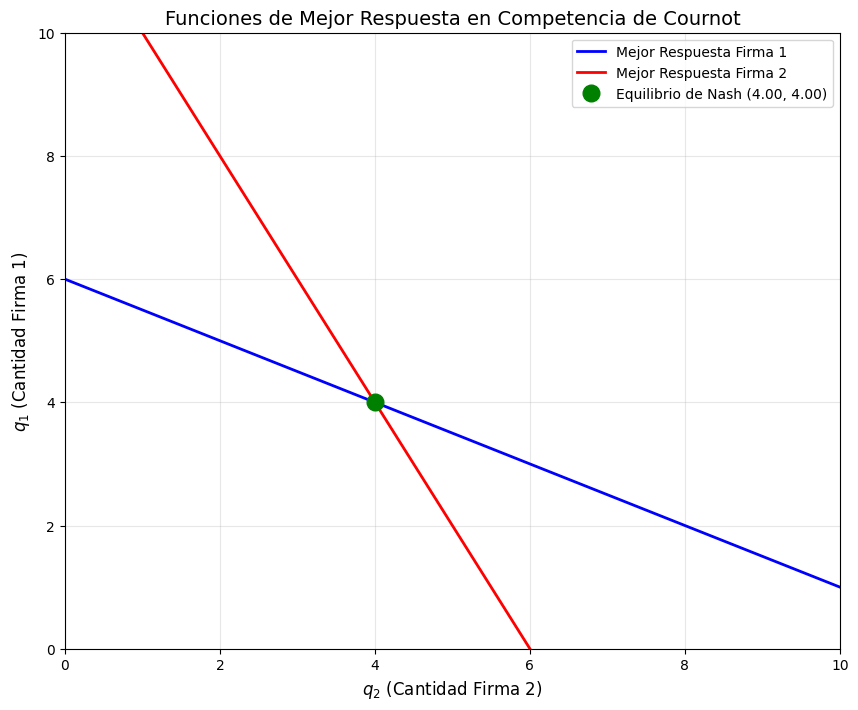

In [5]:
q_range = np.linspace(0, g.max_quantity, 100)

br_1 = best_response(q_range, g.a, g.b, g.c)
br_2 = best_response(q_range, g.a, g.b, g.c)  # symmetric

plt.figure(figsize=(10, 8))
plt.plot(q_range, br_1, 'b-', linewidth=2, label='Mejor Respuesta Firma 1')
plt.plot(br_2, q_range, 'r-', linewidth=2, label='Mejor Respuesta Firma 2')
plt.plot(q_star, q_star, 'go', markersize=12, label=f'Equilibrio de Nash ({q_star:.2f}, {q_star:.2f})')
plt.xlabel('$q_2$ (Cantidad Firma 2)', fontsize=12)
plt.ylabel('$q_1$ (Cantidad Firma 1)', fontsize=12)
plt.title('Funciones de Mejor Respuesta en Competencia de Cournot', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, g.max_quantity])
plt.ylim([0, g.max_quantity])
plt.savefig(f'{SAVE_DIR}/mejor_respuesta.png', dpi=150, bbox_inches='tight')
plt.show()

## Aprendizaje con Regret Matching

In [6]:
g.reset()
rm = dict(map(lambda agent: (agent, RegretMatching(game=g, agent=agent, seed=42)), g.agents))

In [7]:
history = run_experiment(g, rm, iterations=500)
print_strategy(g, rm, 'Regret Matching', q_star)

Estrategias aprendidas (Regret Matching):
  agent_0: Cantidad más probable = 4.0000 (Nash: 4.0000)
  agent_1: Cantidad más probable = 4.0000 (Nash: 4.0000)


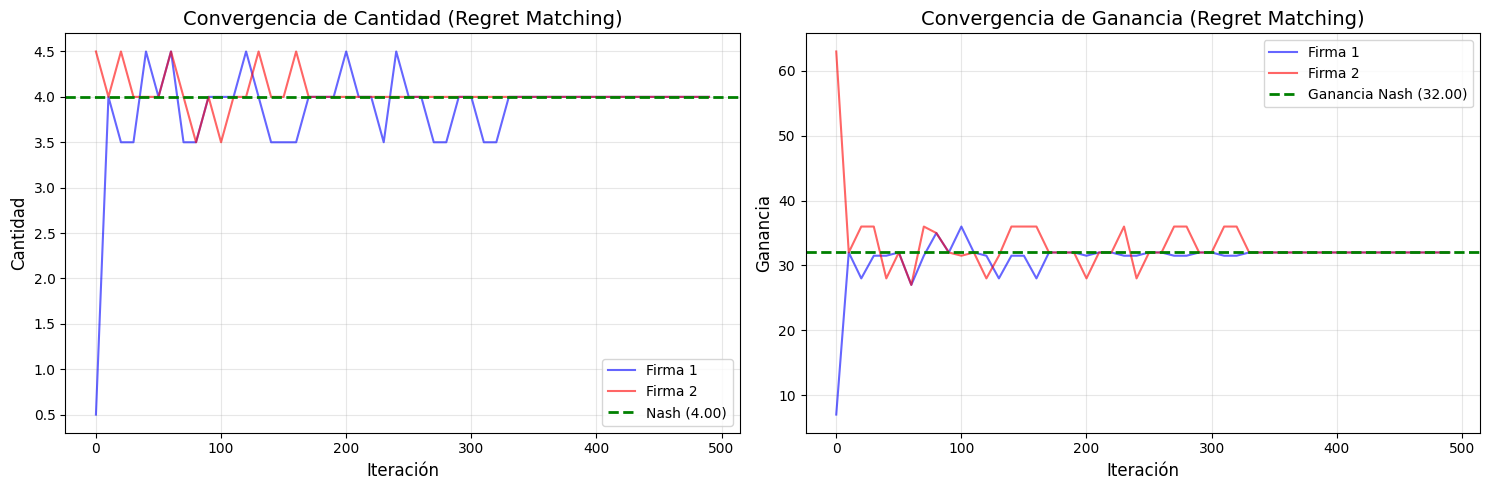

In [8]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Regret Matching', save_path=f'{SAVE_DIR}/convergencia_rm_2jugadores.png')

## Aprendizaje con Fictitious Play

In [9]:
g.reset()
fp = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent, seed=42)), g.agents))

In [10]:
history = run_experiment(g, fp, iterations=500)
print_strategy(g, fp, 'Fictitious Play', q_star)

Estrategias aprendidas (Fictitious Play):
  agent_0: Cantidad más probable = 4.0000 (Nash: 4.0000)
  agent_1: Cantidad más probable = 4.0000 (Nash: 4.0000)


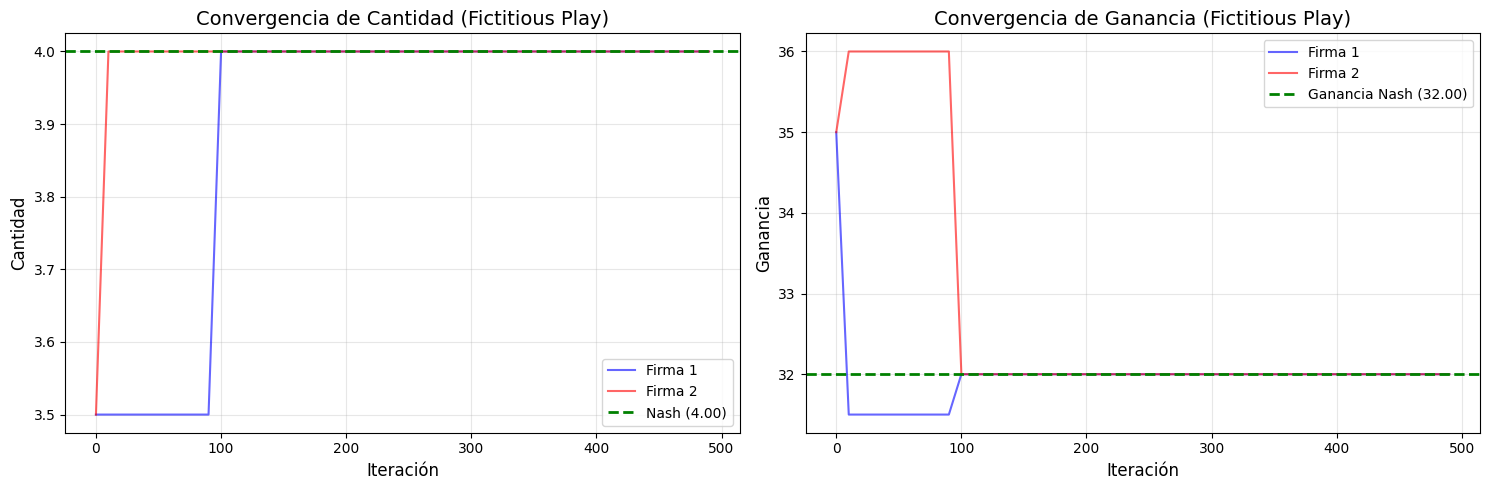

In [11]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Fictitious Play', save_path=f'{SAVE_DIR}/convergencia_fp_2jugadores.png')

## Aprendizaje con Independent Q-Learning (IQL)

IQL trata a cada agente de forma independiente: cada firma aprende una tabla Q sobre sus propias acciones sin modelar explícitamente al oponente, usando exploración ε-greedy con decaimiento de ε.

In [12]:
g.reset()
iql = dict(map(lambda agent: (agent, IndependentQLearning(game=g, agent=agent, seed=42)), g.agents))

history = run_experiment(g, iql, iterations=500)
print_strategy(g, iql, 'Independent Q-Learning', q_star)

Estrategias aprendidas (Independent Q-Learning):
  agent_0: Cantidad más probable = 3.5000 (Nash: 4.0000)
  agent_1: Cantidad más probable = 3.5000 (Nash: 4.0000)


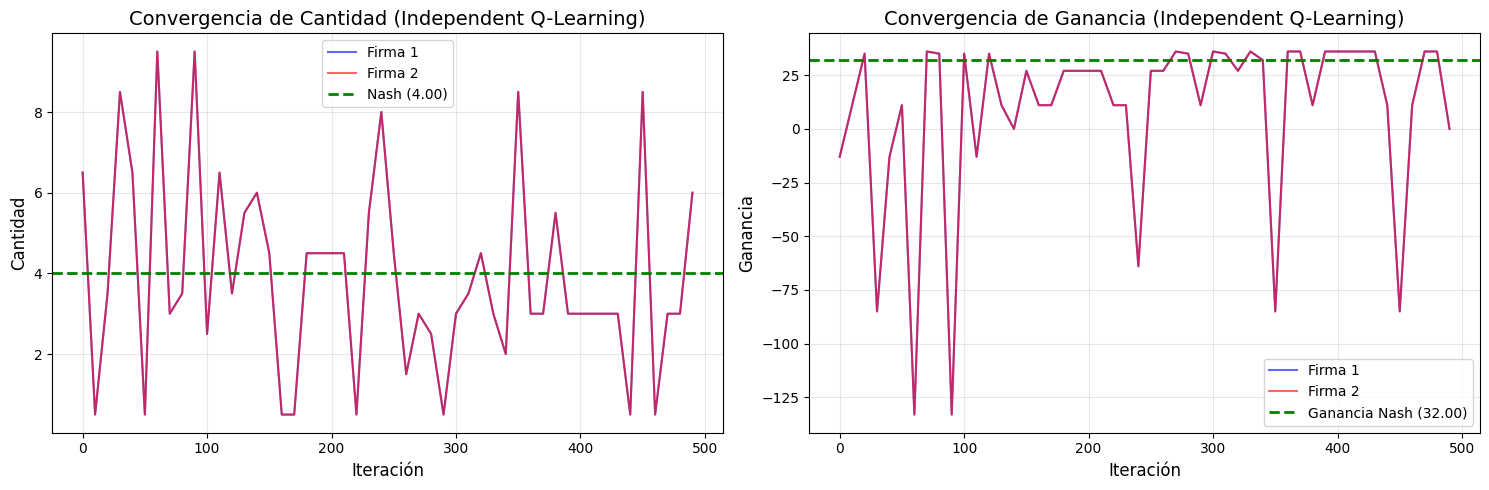

In [13]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Independent Q-Learning', save_path=f'{SAVE_DIR}/convergencia_iql_2jugadores.png')

## Aprendizaje con JAL-AM (Joint Action Learning with Agent Modeling)

JAL-AM modela explícitamente la política del oponente contando sus acciones observadas, luego calcula la función Valor-Acción (AV) como el Q-valor esperado bajo el modelo del oponente. En Cournot, cada firma puede observar la cantidad elegida por el oponente después de cada paso.

In [14]:
g.reset()
jalam = dict(map(lambda agent: (agent, JointActionLearningAM(game=g, agent=agent, seed=42)), g.agents))

history = run_experiment(g, jalam, iterations=500)
print_strategy(g, jalam, 'JAL-AM', q_star)

Estrategias aprendidas (JAL-AM):
  agent_0: Cantidad más probable = 3.5000 (Nash: 4.0000)
  agent_1: Cantidad más probable = 3.5000 (Nash: 4.0000)


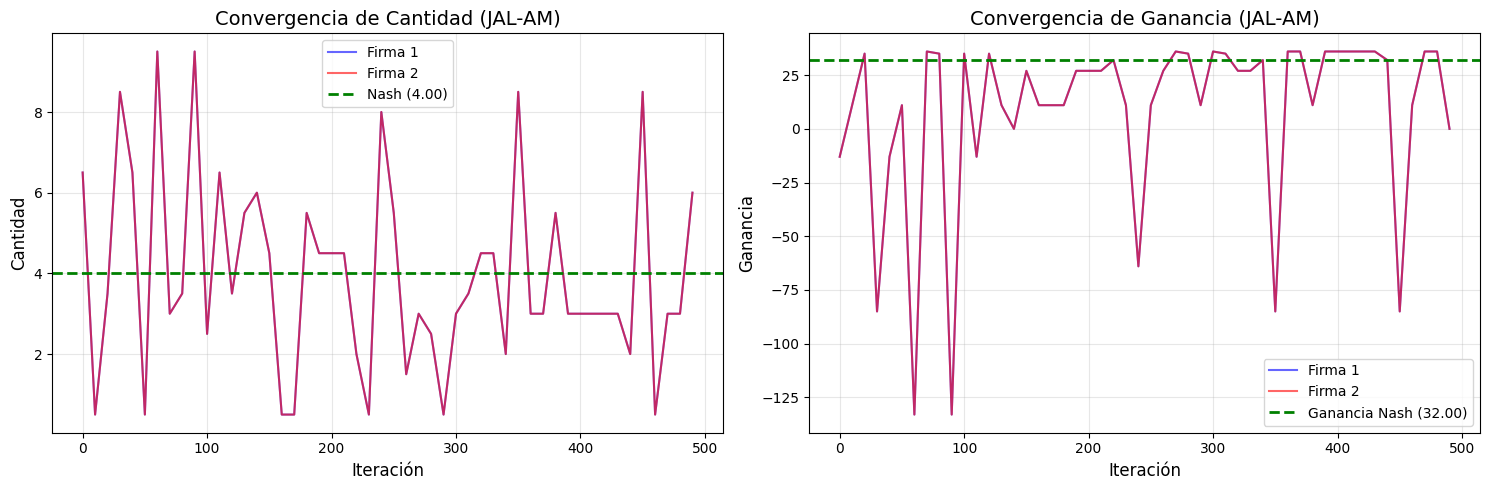

In [15]:
plot_convergence(history, 500, 10, q_star, profit_star, 'JAL-AM', save_path=f'{SAVE_DIR}/convergencia_jalam_2jugadores.png')

## Agente Aleatorio (Baseline)

El Agente Aleatorio selecciona cantidades uniformemente al azar. No aprende y sirve como baseline de referencia.

In [16]:
g.reset()
rand = dict(map(lambda agent: (agent, RandomAgent(game=g, agent=agent, seed=42)), g.agents))

history = run_experiment(g, rand, iterations=500)
avg_q = np.mean(history['q1'] + history['q2'])
avg_profit = np.mean(history['profit1'] + history['profit2'])
print(f"Agente Aleatorio (baseline):")
print(f"  Cantidad promedio: {avg_q:.4f} (Nash: {q_star:.4f})")
print(f"  Ganancia promedio: {avg_profit:.4f} (Nash: {profit_star:.4f}")

Agente Aleatorio (baseline):
  Cantidad promedio: 4.9450 (Nash: 4.0000)
  Ganancia promedio: 5.0350 (Nash: 32.0000


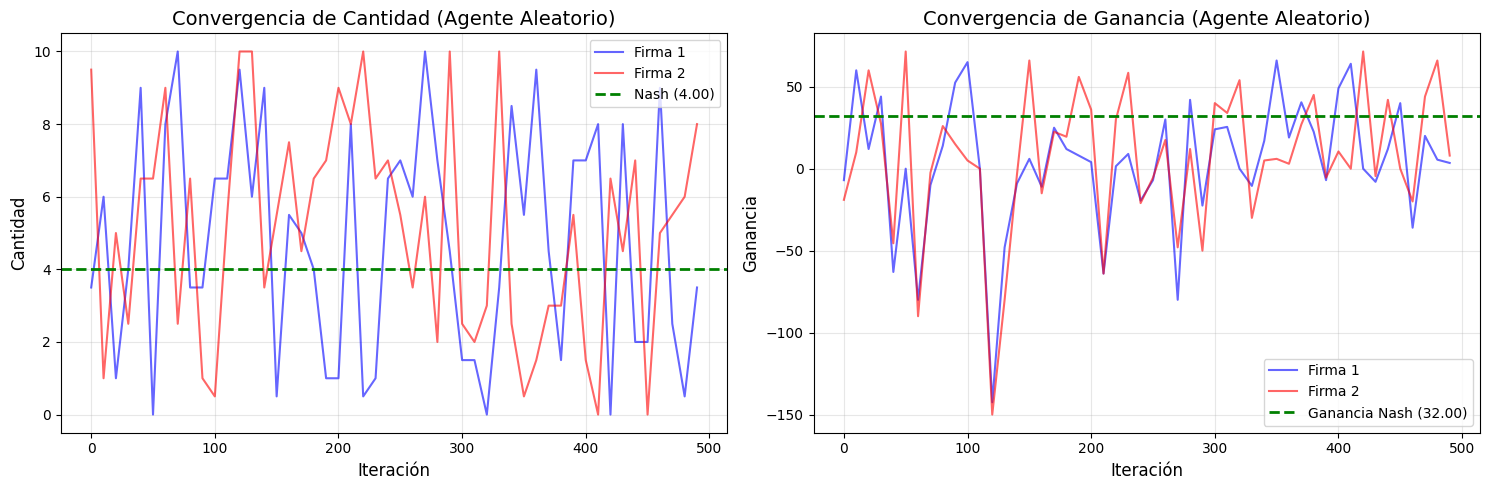

In [17]:
plot_convergence(history, 500, 10, q_star, profit_star, 'Agente Aleatorio', save_path=f'{SAVE_DIR}/convergencia_random_2jugadores.png')

## Comparación de Distribuciones de Estrategia (Todos los Algoritmos)

Comparación de las distribuciones de estrategia aprendidas para los cinco algoritmos versus el Equilibrio de Nash:

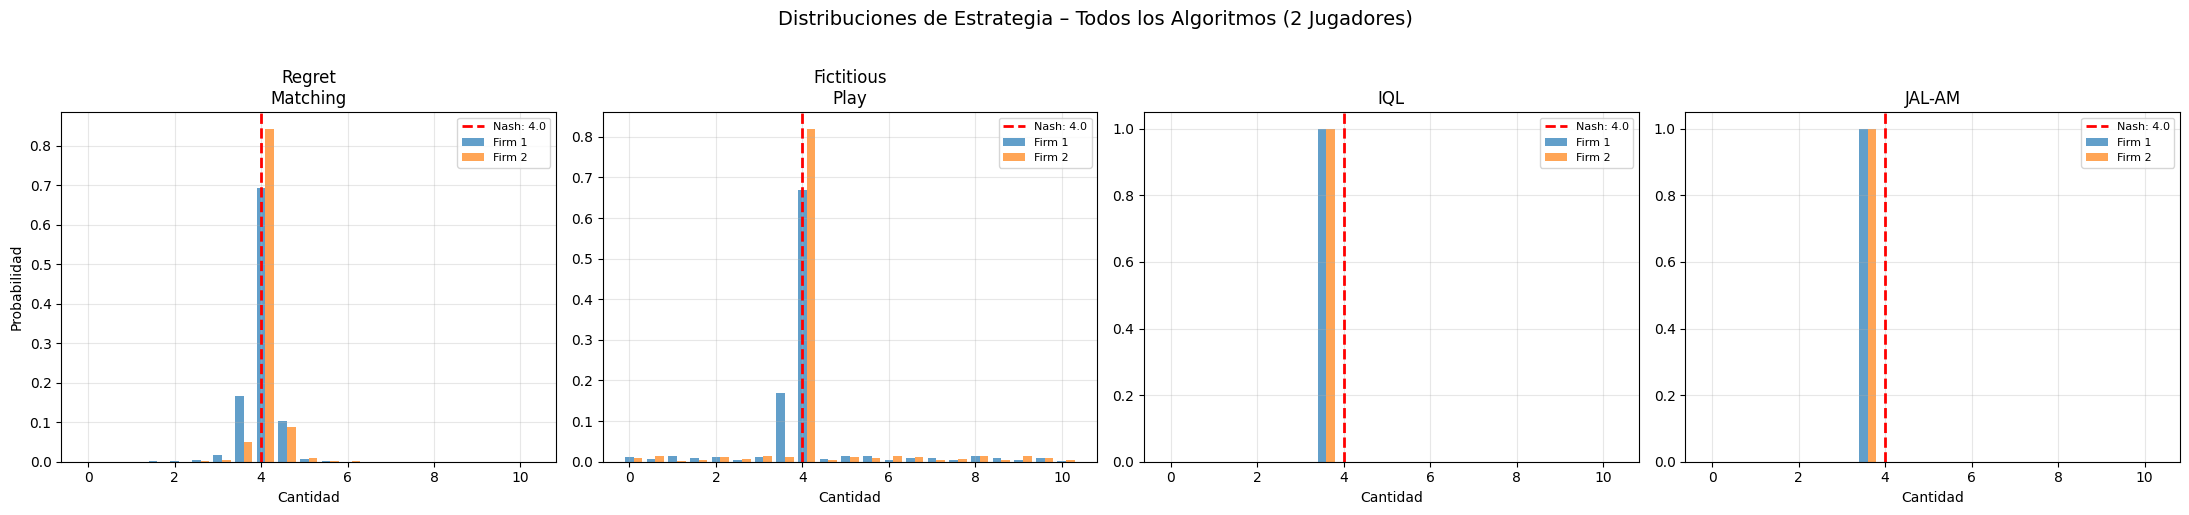

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
algo_info = [
    ('Regret\nMatching', rm),
    ('Fictitious\nPlay', fp),
    ('IQL', iql),
    ('JAL-AM', jalam),
]

for ax, (name, agents_dict) in zip(axes, algo_info):
    for j, agent in enumerate(g.agents):
        policy = agents_dict[agent].policy()
        ax.bar(g._quantities + j * 0.2, policy, alpha=0.7, label=f'Firm {j+1}', width=0.2)
    ax.axvline(x=q_star, color='red', linestyle='--', linewidth=2, label=f'Nash: {q_star:.1f}')
    ax.set_xlabel('Cantidad', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Probabilidad', fontsize=10)
plt.suptitle('Distribuciones de Estrategia – Todos los Algoritmos (2 Jugadores)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/distribuciones_estrategia_2jugadores.png', dpi=150, bbox_inches='tight')
plt.show()

## Experimento Mixto: RM vs FP – ¿Quién llega primero al Equilibrio?

En este experimento las dos firmas usan algoritmos distintos:
- **Firma 0 (azul)**: Regret Matching
- **Firma 1 (naranja)**: Fictitious Play

Se registra en cada iteración la cantidad más probable según la política aprendida (`argmax` de la distribución) y se detecta automáticamente cuál agente alcanza primero la cantidad de Nash (dentro de la resolución de la grilla discreta).

In [19]:
g.reset()
rm_mix = RegretMatching(game=g, agent=g.agents[0], seed=42)
fp_mix = FictitiousPlay(game=g,  agent=g.agents[1], seed=42)
mixed_agents = {g.agents[0]: rm_mix, g.agents[1]: fp_mix}

iterations_mix = 500
history_mix = {'q_rm': [], 'q_fp': [], 'policy_q_rm': [], 'policy_q_fp': []}

for i in range(iterations_mix):
    actions = {agent: mixed_agents[agent].action() for agent in g.agents}
    obs, rewards, terms, truncs, infos = g.step(actions)

    history_mix['q_rm'].append(g._quantities[actions[g.agents[0]]])
    history_mix['q_fp'].append(g._quantities[actions[g.agents[1]]])
    history_mix['policy_q_rm'].append(g._quantities[np.argmax(rm_mix.policy())])
    history_mix['policy_q_fp'].append(g._quantities[np.argmax(fp_mix.policy())])

# Tolerancia = un paso de acción (resolución de la grilla discreta)
tol = g._quantities[1] - g._quantities[0]
conv_rm = next((i for i, q in enumerate(history_mix['policy_q_rm']) if abs(q - q_star) <= tol), None)
conv_fp = next((i for i, q in enumerate(history_mix['policy_q_fp']) if abs(q - q_star) <= tol), None)

print(f"Experimento mixto: firma 0 = RM, firma 1 = FP  (tolerancia ±{tol:.2f})")
print(f"  RM alcanza el Nash en iteración: {conv_rm}")
print(f"  FP alcanza el Nash en iteración: {conv_fp}")
if conv_rm is not None and conv_fp is not None:
    winner = 'RM' if conv_rm < conv_fp else 'FP'
    print(f"  → {winner} llega primero al equilibrio")
elif conv_rm is not None:
    print("  → RM llega al equilibrio; FP no converge en las iteraciones dadas")
elif conv_fp is not None:
    print("  → FP llega al equilibrio; RM no converge en las iteraciones dadas")

Experimento mixto: firma 0 = RM, firma 1 = FP  (tolerancia ±0.50)
  RM alcanza el Nash en iteración: 1
  FP alcanza el Nash en iteración: 7
  → RM llega primero al equilibrio


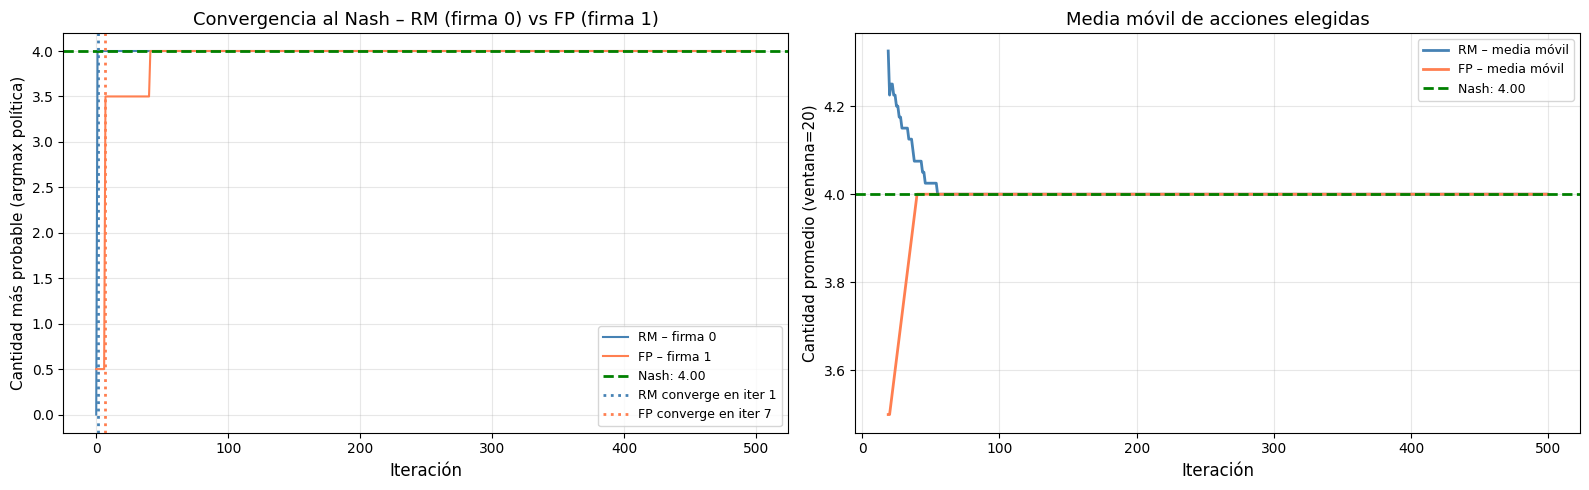

In [20]:
window = 20

q_rm_arr = np.array(history_mix['q_rm'])
q_fp_arr = np.array(history_mix['q_fp'])
roll_rm = np.convolve(q_rm_arr, np.ones(window) / window, mode='valid')
roll_fp = np.convolve(q_fp_arr, np.ones(window) / window, mode='valid')
roll_x = np.arange(window - 1, iterations_mix)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Política aprendida (argmax) en cada iteración
ax1.plot(history_mix['policy_q_rm'], color='steelblue', linewidth=1.5, label='RM – firma 0')
ax1.plot(history_mix['policy_q_fp'], color='coral',     linewidth=1.5, label='FP – firma 1')
ax1.axhline(y=q_star, color='green', linestyle='--', linewidth=2, label=f'Nash: {q_star:.2f}')
if conv_rm is not None:
    ax1.axvline(x=conv_rm, color='steelblue', linestyle=':', linewidth=2,
                label=f'RM converge en iter {conv_rm}')
if conv_fp is not None:
    ax1.axvline(x=conv_fp, color='coral', linestyle=':', linewidth=2,
                label=f'FP converge en iter {conv_fp}')
ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Cantidad más probable (argmax política)', fontsize=11)
ax1.set_title('Convergencia al Nash – RM (firma 0) vs FP (firma 1)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Media móvil de las acciones elegidas
ax2.plot(roll_x, roll_rm, color='steelblue', linewidth=2, label='RM – media móvil')
ax2.plot(roll_x, roll_fp, color='coral',     linewidth=2, label='FP – media móvil')
ax2.axhline(y=q_star, color='green', linestyle='--', linewidth=2, label=f'Nash: {q_star:.2f}')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel(f'Cantidad promedio (ventana={window})', fontsize=11)
ax2.set_title('Media móvil de acciones elegidas', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/experimento_mixto_rm_vs_fp.png', dpi=150, bbox_inches='tight')
plt.show()

# Competencia de Cournot con Tres Jugadores

Ahora probamos el juego con 3 firmas para ver cómo afecta la competencia a los resultados de equilibrio.

## Equilibrio de Nash para $n$ Jugadores

Para $n$ firmas, el Equilibrio de Nash es:
- Cantidad de equilibrio por firma: $q^* = \frac{a - c}{(n+1)b}$
- Cantidad total de mercado: $Q^* = n \cdot q^*$
- Precio de equilibrio: $P^* = a - b \cdot Q^*$

In [21]:
# Create 3-player game with same parameters
g3 = Cournot(a=25.0, b=2.0, c=1.0, n_players=3, max_quantity=10, num_actions=21)
g3.reset()

print(f"Número de jugadores: {g3.n_players}")
print(f"Agentes: {g3.agents}")

Número de jugadores: 3
Agentes: ['agent_0', 'agent_1', 'agent_2']


## Equilibrio de Nash (3 Jugadores)

In [22]:
q_star_3, P_star_3, profit_star_3 = g3.get_nash_equilibrium()
print(f"Equilibrio de Nash (3 jugadores):")
print(f"  Cantidad por firma: {q_star_3:.4f}")
print(f"  Cantidad total: {3*q_star_3:.4f}")
print(f"  Precio: {P_star_3:.4f}")
print(f"  Ganancia por firma: {profit_star_3:.4f}")
print(f"\nComparación con 2 jugadores:")
print(f"  2 jugadores: q*={q_star:.4f}, P*={P_star:.4f}, π*={profit_star:.4f}")
print(f"  3 jugadores: q*={q_star_3:.4f}, P*={P_star_3:.4f}, π*={profit_star_3:.4f}")

Equilibrio de Nash (3 jugadores):
  Cantidad por firma: 3.0000
  Cantidad total: 9.0000
  Precio: 7.0000
  Ganancia por firma: 18.0000

Comparación con 2 jugadores:
  2 jugadores: q*=4.0000, P*=9.0000, π*=32.0000
  3 jugadores: q*=3.0000, P*=7.0000, π*=18.0000


## Verificación del Equilibrio de Nash

In [23]:
# Test with Nash equilibrium quantities
g3.reset()
nash_action_3 = np.argmin(np.abs(g3._quantities - q_star_3))
actions_3 = {agent: nash_action_3 for agent in g3.agents}
obs, rewards, terms, truncs, infos = g3.step(actions_3)
g3.render()
print(f"\nGanancia Nash esperada: {profit_star_3:.4f}")

agent_0: quantity=3.00, profit=18.00
agent_1: quantity=3.00, profit=18.00
agent_2: quantity=3.00, profit=18.00

Ganancia Nash esperada: 18.0000


## Aprendizaje con Regret Matching (3 Players)

In [24]:
g3.reset()
rm3 = dict(map(lambda agent: (agent, RegretMatching(game=g3, agent=agent, seed=42)), g3.agents))

In [25]:
history_3 = run_experiment_n(g3, rm3, iterations=1000)
print_strategy(g3, rm3, 'Regret Matching - 3 players', q_star_3)

Estrategias aprendidas (Regret Matching - 3 players):
  agent_0: Cantidad más probable = 3.0000 (Nash: 3.0000)
  agent_1: Cantidad más probable = 3.0000 (Nash: 3.0000)
  agent_2: Cantidad más probable = 3.0000 (Nash: 3.0000)


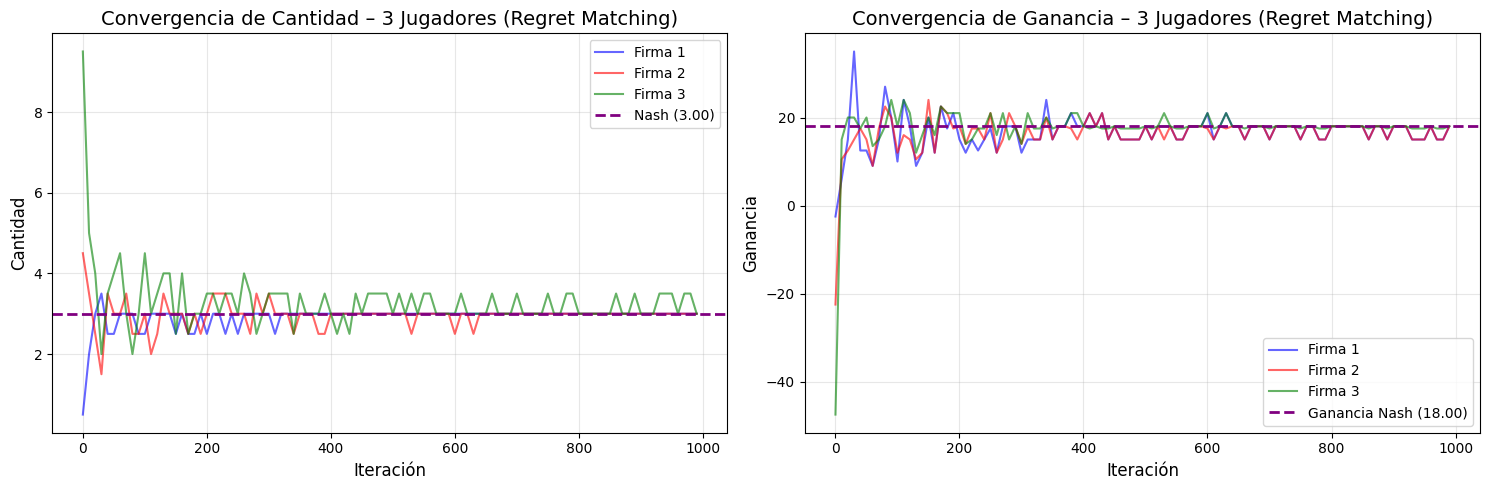

In [26]:
plot_convergence_n(g3, history_3, 1000, 10, q_star_3, profit_star_3, '3 Jugadores (Regret Matching)', save_path=f'{SAVE_DIR}/convergencia_rm_3jugadores.png')

## Aprendizaje con Fictitious Play (3 Players)

In [27]:
g3.reset()
fp3 = dict(map(lambda agent: (agent, FictitiousPlay(game=g3, agent=agent, seed=42)), g3.agents))

In [28]:
history_fp3 = run_experiment_n(g3, fp3, iterations=1000)
print_strategy(g3, fp3, 'Fictitious Play - 3 players', q_star_3)

Estrategias aprendidas (Fictitious Play - 3 players):
  agent_0: Cantidad más probable = 3.0000 (Nash: 3.0000)
  agent_1: Cantidad más probable = 3.0000 (Nash: 3.0000)
  agent_2: Cantidad más probable = 3.0000 (Nash: 3.0000)


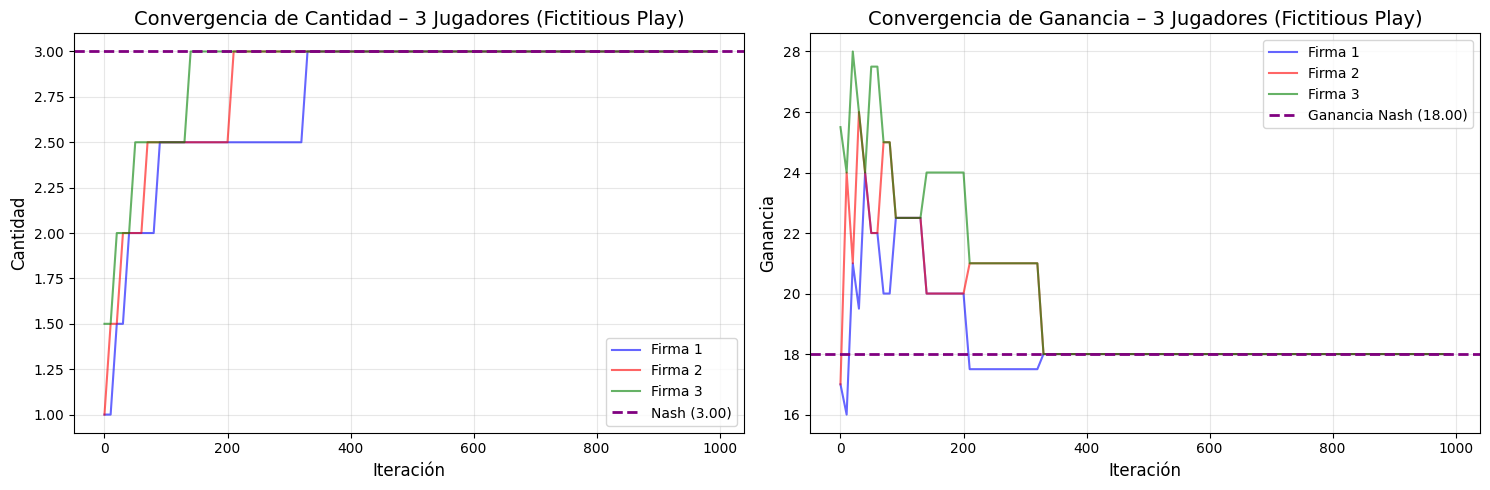

In [29]:
plot_convergence_n(g3, history_fp3, 1000, 10, q_star_3, profit_star_3, '3 Jugadores (Fictitious Play)', save_path=f'{SAVE_DIR}/convergencia_fp_3jugadores.png')

## Distribución de Estrategias – RM y FP (3 Jugadores)

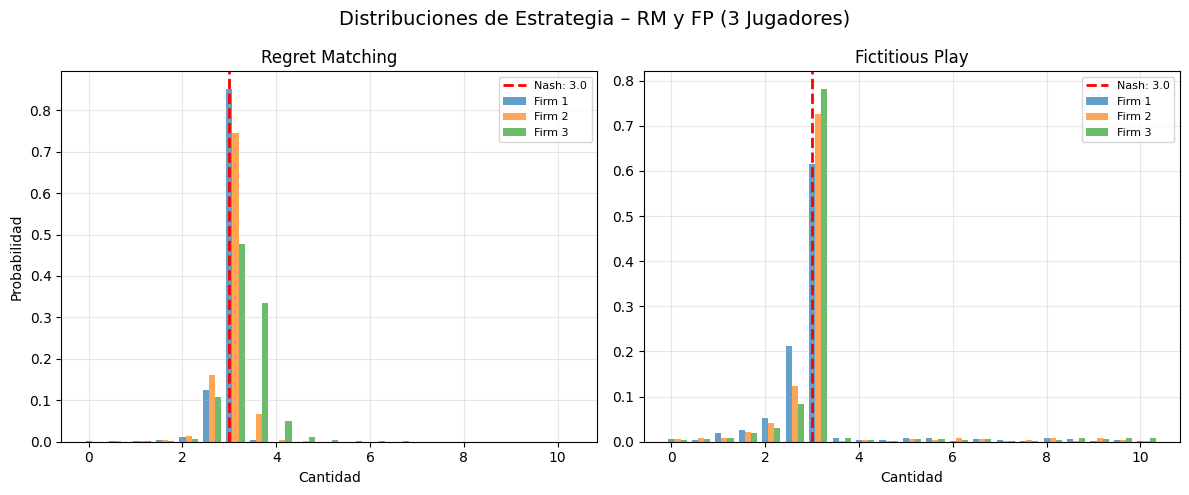

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
algo_info_3 = [('Regret Matching', rm3), ('Fictitious Play', fp3)]

for ax, (name, agents_dict) in zip(axes, algo_info_3):
    for j, agent in enumerate(g3.agents):
        policy = agents_dict[agent].policy()
        ax.bar(g3._quantities + j * 0.13, policy, alpha=0.7, label=f'Firm {j+1}', width=0.13)
    ax.axvline(x=q_star_3, color='red', linestyle='--', linewidth=2, label=f'Nash: {q_star_3:.1f}')
    ax.set_xlabel('Cantidad', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Probabilidad', fontsize=10)
plt.suptitle('Distribuciones de Estrategia – RM y FP (3 Jugadores)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/distribuciones_estrategia_3jugadores.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparación: 2 Jugadores vs 3 Jugadores

Comparamos los resultados de mercado con distintos números de firmas:

In [31]:
# Create comparison table
comparison_data = {
    'Number of Firms': [2, 3],
    'q* (per firm)': [q_star, q_star_3],
    'Q* (total)': [2*q_star, 3*q_star_3],
    'P* (price)': [P_star, P_star_3],
    'π* (per firm)': [profit_star, profit_star_3],
    'Total Industry Profit': [2*profit_star, 3*profit_star_3]
}

print("Impact of Number of Firms on Market Outcomes:")
print("="*80)
print(f"{'Firms':<10} {'q* (each)':<12} {'Q* (total)':<12} {'P*':<10} {'π* (each)':<12} {'Total π*':<12}")
print("="*80)
for i in range(len(comparison_data['Number of Firms'])):
    n = comparison_data['Number of Firms'][i]
    q = comparison_data['q* (per firm)'][i]
    Q = comparison_data['Q* (total)'][i]
    P = comparison_data['P* (price)'][i]
    pi = comparison_data['π* (per firm)'][i]
    total_pi = comparison_data['Total Industry Profit'][i]
    print(f"{n:<10} {q:<12.4f} {Q:<12.4f} {P:<10.4f} {pi:<12.4f} {total_pi:<12.4f}")
print("="*80)
print("\nObservaciones:")
print("  • Al aumentar el número de firmas:")
print("    - Cada firma produce menos (q* disminuye)")
print("    - La cantidad total de mercado aumenta (Q* aumenta)")
print("    - El precio disminuye (P* disminuye)")
print("    - La ganancia por firma disminuye (π* disminuye)")
print("    - La ganancia total de la industria disminuye")
print("  • El mercado se vuelve más competitivo, aproximándose a la competencia perfecta")

Impact of Number of Firms on Market Outcomes:
Firms      q* (each)    Q* (total)   P*         π* (each)    Total π*    
2          4.0000       8.0000       9.0000     32.0000      64.0000     
3          3.0000       9.0000       7.0000     18.0000      54.0000     

Observaciones:
  • Al aumentar el número de firmas:
    - Cada firma produce menos (q* disminuye)
    - La cantidad total de mercado aumenta (Q* aumenta)
    - El precio disminuye (P* disminuye)
    - La ganancia por firma disminuye (π* disminuye)
    - La ganancia total de la industria disminuye
  • El mercado se vuelve más competitivo, aproximándose a la competencia perfecta


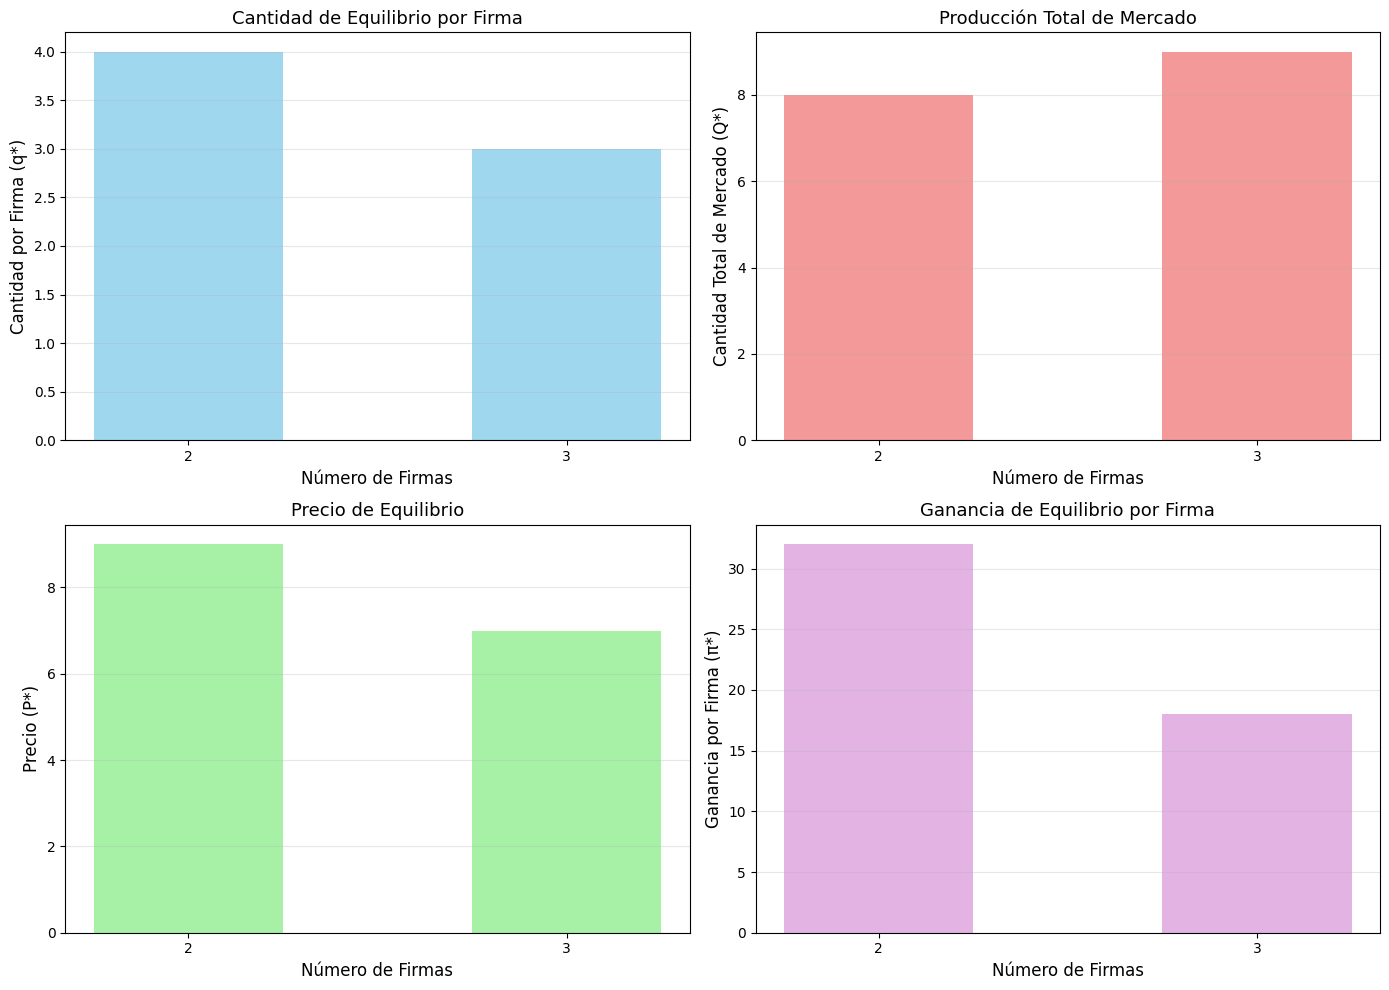

In [32]:
# Visualize the comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

n_firms = [2, 3]
q_per_firm = [q_star, q_star_3]
Q_total = [2*q_star, 3*q_star_3]
prices = [P_star, P_star_3]
profit_per_firm = [profit_star, profit_star_3]

# Quantity per firm
ax1.bar(n_firms, q_per_firm, color='skyblue', alpha=0.8, width=0.5)
ax1.set_xlabel('Número de Firmas', fontsize=12)
ax1.set_ylabel('Cantidad por Firma (q*)', fontsize=12)
ax1.set_title('Cantidad de Equilibrio por Firma', fontsize=13)
ax1.set_xticks(n_firms)
ax1.grid(True, alpha=0.3, axis='y')

# Total market quantity
ax2.bar(n_firms, Q_total, color='lightcoral', alpha=0.8, width=0.5)
ax2.set_xlabel('Número de Firmas', fontsize=12)
ax2.set_ylabel('Cantidad Total de Mercado (Q*)', fontsize=12)
ax2.set_title('Producción Total de Mercado', fontsize=13)
ax2.set_xticks(n_firms)
ax2.grid(True, alpha=0.3, axis='y')

# Price
ax3.bar(n_firms, prices, color='lightgreen', alpha=0.8, width=0.5)
ax3.set_xlabel('Número de Firmas', fontsize=12)
ax3.set_ylabel('Precio (P*)', fontsize=12)
ax3.set_title('Precio de Equilibrio', fontsize=13)
ax3.set_xticks(n_firms)
ax3.grid(True, alpha=0.3, axis='y')

# Profit per firm
ax4.bar(n_firms, profit_per_firm, color='plum', alpha=0.8, width=0.5)
ax4.set_xlabel('Número de Firmas', fontsize=12)
ax4.set_ylabel('Ganancia por Firma (π*)', fontsize=12)
ax4.set_title('Ganancia de Equilibrio por Firma', fontsize=13)
ax4.set_xticks(n_firms)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparacion_2vs3jugadores.png', dpi=150, bbox_inches='tight')
plt.show()

# Experimento con Parámetros de Mercado Medio – 3 Jugadores

Antes de escalar al mercado grande, evaluamos un mercado de tamaño intermedio: $a=50$, $b=1$, $c=10$, con **51 acciones** posibles entre 0 y 25 unidades y **3 firmas** competidoras.

El equilibrio de Nash teórico para este mercado es:
$$q^* = \frac{a - c}{(n+1)\,b} = \frac{50 - 10}{4 \cdot 1} = 10$$

El espacio de acción es más del doble que en los experimentos anteriores, lo que permite evaluar la escalabilidad de RM y FP antes del salto al mercado grande ($q^*=22.5$, 91 acciones).

In [101]:
# Parámetros del mercado medio (3 jugadores)
g_med = Cournot(a=50.0, b=1.0, c=10.0, n_players=3, max_quantity=25, num_actions=51)
g_med.reset()

q_star_med, P_star_med, profit_star_med = g_med.get_nash_equilibrium()
print(f"Equilibrio de Nash – Mercado Medio, 3 Firmas:")
print(f"  Parámetros: a={g_med.a}, b={g_med.b}, c={g_med.c}, n={g_med.n_players}")
print(f"  Acciones disponibles: {g_med._num_actions}  (paso = {g_med.max_quantity / (g_med._num_actions - 1):.2f})")
print(f"  Cantidad por firma  (q*): {q_star_med:.4f}")
print(f"  Cantidad total      (Q*): {3*q_star_med:.4f}")
print(f"  Precio              (P*): {P_star_med:.4f}")
print(f"  Ganancia por firma  (π*): {profit_star_med:.4f}")

Equilibrio de Nash – Mercado Medio, 3 Firmas:
  Parámetros: a=50.0, b=1.0, c=10.0, n=3
  Acciones disponibles: 51  (paso = 0.50)
  Cantidad por firma  (q*): 10.0000
  Cantidad total      (Q*): 30.0000
  Precio              (P*): 20.0000
  Ganancia por firma  (π*): 100.0000


## Regret Matching – Mercado Medio

In [102]:
ITERS_MED = 1200

g_med.reset()
rm_med = dict(map(lambda agent: (agent, RegretMatching(game=g_med, agent=agent, seed=42)), g_med.agents))
history_rm_med = run_experiment_n(g_med, rm_med, iterations=ITERS_MED, breakpoint=100)
print_strategy(g_med, rm_med, 'Regret Matching – Mercado Medio', q_star_med)

Iteration 0/1200 | rewards -> agent_0: -247.50, agent_1: -262.50, agent_2: -315.00
Iteration 100/1200 | rewards -> agent_0: 110.50, agent_1: 104.00, agent_2: 136.50
Iteration 200/1200 | rewards -> agent_0: 115.00, agent_1: 97.75, agent_2: 115.00
Iteration 300/1200 | rewards -> agent_0: 120.75, agent_1: 97.75, agent_2: 109.25
Iteration 400/1200 | rewards -> agent_0: 115.00, agent_1: 109.25, agent_2: 103.50
Iteration 500/1200 | rewards -> agent_0: 105.00, agent_1: 105.00, agent_2: 90.00
Iteration 600/1200 | rewards -> agent_0: 105.00, agent_1: 99.75, agent_2: 105.00
Iteration 700/1200 | rewards -> agent_0: 104.50, agent_1: 110.00, agent_2: 104.50
Iteration 800/1200 | rewards -> agent_0: 114.00, agent_1: 114.00, agent_2: 108.00
Iteration 900/1200 | rewards -> agent_0: 100.00, agent_1: 100.00, agent_2: 100.00
Iteration 1000/1200 | rewards -> agent_0: 95.00, agent_1: 99.75, agent_2: 95.00
Iteration 1100/1200 | rewards -> agent_0: 105.00, agent_1: 105.00, agent_2: 99.75
Estrategias aprendida

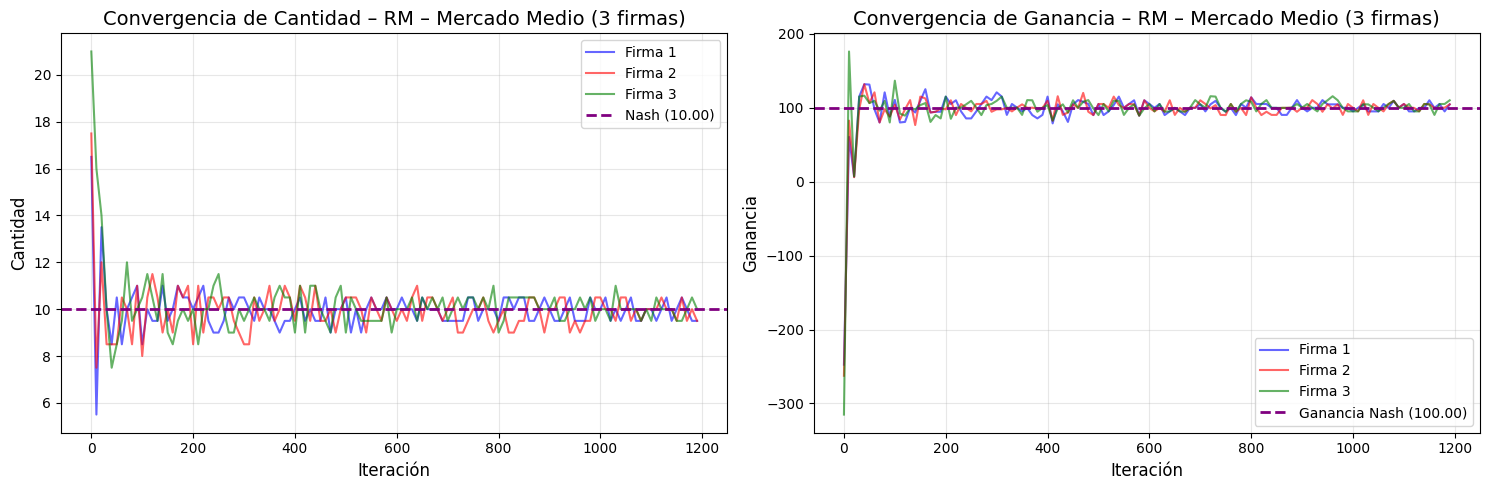

In [103]:
plot_convergence_n(g_med, history_rm_med, ITERS_MED, 10, q_star_med, profit_star_med,
                   'RM – Mercado Medio (3 firmas)',
                   save_path=f'{SAVE_DIR}/convergencia_rm_3j_medio.png')

## Fictitious Play – Mercado Medio

In [104]:
g_med.reset()
fp_med = dict(map(lambda agent: (agent, FictitiousPlay(game=g_med, agent=agent, seed=42)), g_med.agents))
history_fp_med = run_experiment_n(g_med, fp_med, iterations=ITERS_MED)
print_strategy(g_med, fp_med, 'Fictitious Play – Mercado Medio', q_star_med)

Iteration 0/1200 | rewards -> agent_0: 123.75, agent_1: 132.00, agent_2: 132.00
Iteration 50/1200 | rewards -> agent_0: 123.25, agent_1: 123.25, agent_2: 123.25
Iteration 100/1200 | rewards -> agent_0: 114.75, agent_1: 121.50, agent_2: 121.50
Iteration 150/1200 | rewards -> agent_0: 117.00, agent_1: 117.00, agent_2: 117.00
Iteration 200/1200 | rewards -> agent_0: 108.00, agent_1: 114.00, agent_2: 114.00
Iteration 250/1200 | rewards -> agent_0: 109.25, agent_1: 109.25, agent_2: 109.25
Iteration 300/1200 | rewards -> agent_0: 109.25, agent_1: 109.25, agent_2: 109.25
Iteration 350/1200 | rewards -> agent_0: 109.25, agent_1: 109.25, agent_2: 109.25
Iteration 400/1200 | rewards -> agent_0: 109.25, agent_1: 109.25, agent_2: 109.25
Iteration 450/1200 | rewards -> agent_0: 104.50, agent_1: 104.50, agent_2: 110.00
Iteration 500/1200 | rewards -> agent_0: 99.75, agent_1: 105.00, agent_2: 105.00
Iteration 550/1200 | rewards -> agent_0: 99.75, agent_1: 105.00, agent_2: 105.00
Iteration 600/1200 | 

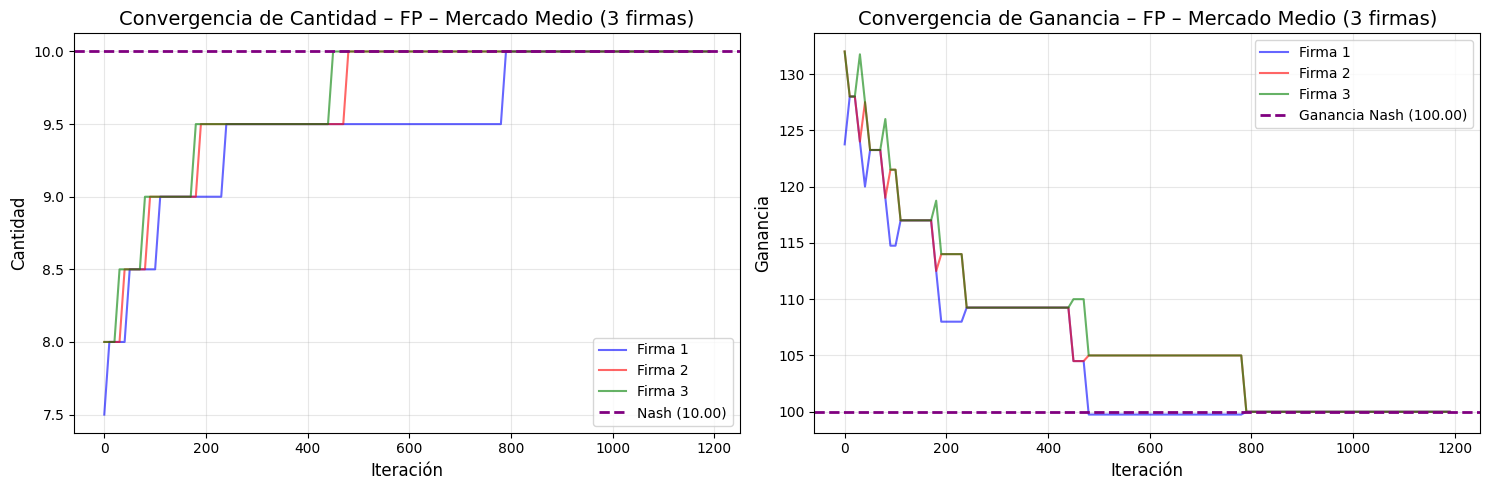

In [105]:
plot_convergence_n(g_med, history_fp_med, ITERS_MED, 10, q_star_med, profit_star_med,
                   'FP – Mercado Medio (3 firmas)',
                   save_path=f'{SAVE_DIR}/convergencia_fp_3j_medio.png')

## Distribuciones de Estrategia – RM y FP – Mercado Medio (3 Firmas)

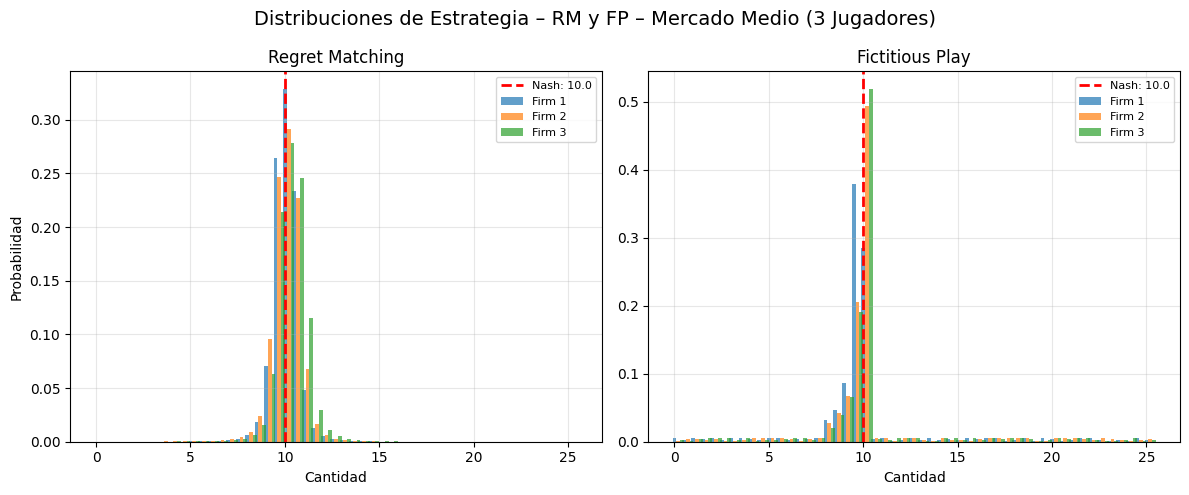

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
algo_info_med = [('Regret Matching', rm_med), ('Fictitious Play', fp_med)]

for ax, (name, agents_dict) in zip(axes, algo_info_med):
    for j, agent in enumerate(g_med.agents):
        policy = agents_dict[agent].policy()
        ax.bar(g_med._quantities + j * 0.2, policy, alpha=0.7, label=f'Firm {j+1}', width=0.2)
    ax.axvline(x=q_star_med, color='red', linestyle='--', linewidth=2, label=f'Nash: {q_star_med:.1f}')
    ax.set_xlabel('Cantidad', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Probabilidad', fontsize=10)
plt.suptitle('Distribuciones de Estrategia – RM y FP – Mercado Medio (3 Jugadores)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/distribuciones_estrategia_3jugadores_medio.png', dpi=150, bbox_inches='tight')
plt.show()

## Experimento Mixto: 3 Firmas (2 RM + 1 FP) – Mercado Medio


In [130]:
# Juego de 3 firmas con parámetros del Mercado Medio
g_med3 = Cournot(a=50.0, b=1.0, c=10.0, n_players=3, max_quantity=25, num_actions=51)
g_med3.reset()

q_star_med3, P_star_med3, profit_star_med3 = g_med3.get_nash_equilibrium()
print(f"Equilibrio de Nash – Mercado Medio, 3 Firmas:")
print(f"  Cantidad por firma  (q*): {q_star_med3:.4f}")
print(f"  Cantidad total      (Q*): {3*q_star_med3:.4f}")
print(f"  Precio              (P*): {P_star_med3:.4f}")
print(f"  Ganancia por firma  (π*): {profit_star_med3:.4f}")

Equilibrio de Nash – Mercado Medio, 3 Firmas:
  Cantidad por firma  (q*): 10.0000
  Cantidad total      (Q*): 30.0000
  Precio              (P*): 20.0000
  Ganancia por firma  (π*): 100.0000


In [137]:
# Firmas 0 y 1 → RM; Firmas 2 y 3 → FP
g_med3.reset()
mixed3_agents = {}
for i, agent in enumerate(g_med3.agents):
    if i < 2:
        mixed3_agents[agent] = RegretMatching(game=g_med3, agent=agent, seed=42)
    else:
        mixed3_agents[agent] = FictitiousPlay(game=g_med3, agent=agent, seed=42)

ITERS_MED3 = 2000
history_mix3 = run_experiment_n(g_med3, mixed3_agents, iterations=ITERS_MED3)

print("Estrategias aprendidas (Experimento Mixto – 3 Firmas):")
for i, agent in enumerate(g_med3.agents):
    algo = 'RM' if i < 2 else 'FP'
    q = g_med3._quantities[np.argmax(mixed3_agents[agent].policy())]
    print(f"  Firma {i} ({algo}): q = {q:.4f}  (Nash: {q_star_med3:.4f})")

Iteration 0/2000 | rewards -> agent_0: 30.25, agent_1: 115.50, agent_2: 44.00
Iteration 50/2000 | rewards -> agent_0: 105.00, agent_1: 120.75, agent_2: 84.00
Iteration 100/2000 | rewards -> agent_0: 110.00, agent_1: 105.00, agent_2: 85.00
Iteration 150/2000 | rewards -> agent_0: 110.25, agent_1: 110.25, agent_2: 89.25
Iteration 200/2000 | rewards -> agent_0: 110.25, agent_1: 110.25, agent_2: 89.25
Iteration 250/2000 | rewards -> agent_0: 104.50, agent_1: 104.50, agent_2: 80.75
Iteration 300/2000 | rewards -> agent_0: 110.00, agent_1: 115.50, agent_2: 93.50
Iteration 350/2000 | rewards -> agent_0: 105.00, agent_1: 115.50, agent_2: 89.25
Iteration 400/2000 | rewards -> agent_0: 99.75, agent_1: 104.50, agent_2: 85.50
Iteration 450/2000 | rewards -> agent_0: 105.00, agent_1: 105.00, agent_2: 90.00
Iteration 500/2000 | rewards -> agent_0: 105.00, agent_1: 110.25, agent_2: 94.50
Iteration 550/2000 | rewards -> agent_0: 99.75, agent_1: 104.50, agent_2: 85.50
Iteration 600/2000 | rewards -> ag

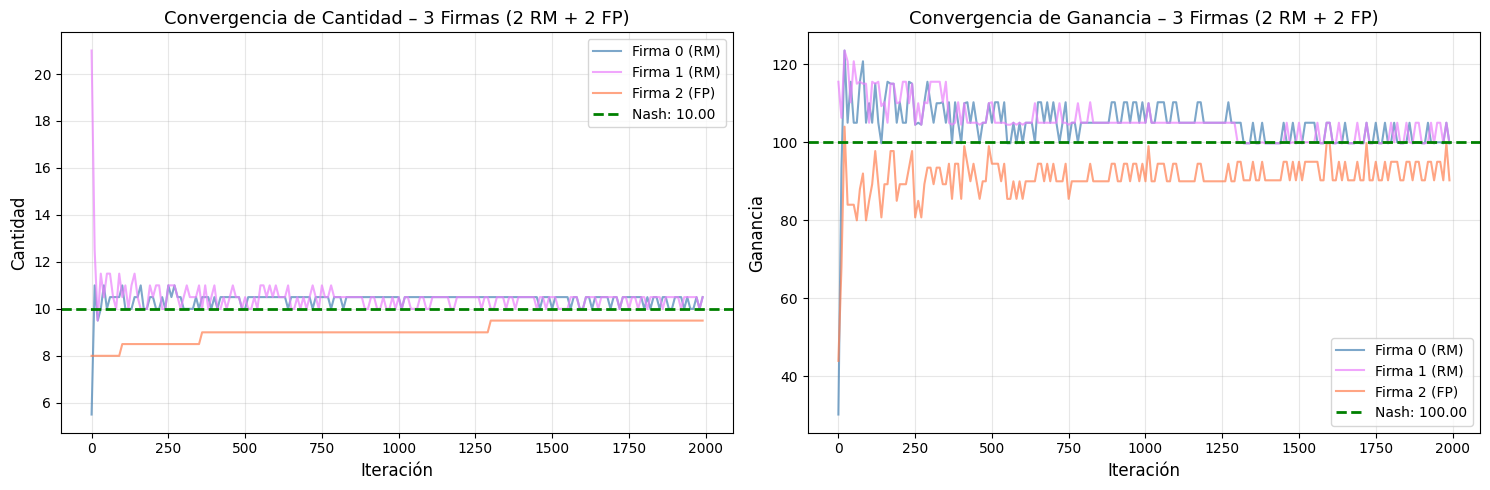

In [142]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
x = range(0, ITERS_MED3, 10)

rm_colors = ['steelblue', '#EA80FC']
fp_colors = ['coral', 'tomato']

for i, agent in enumerate(g_med3.agents):
    if i < 2:
        color, label = rm_colors[i], f'Firma {i} (RM)'
    else:
        color, label = fp_colors[i - 2], f'Firma {i} (FP)'
    ax1.plot(x, history_mix3['q'][agent], color=color, alpha=0.7, linewidth=1.5, label=label)
    ax2.plot(x, history_mix3['profit'][agent], color=color, alpha=0.7, linewidth=1.5, label=label)

ax1.axhline(y=q_star_med3, color='green', linestyle='--', linewidth=2, label=f'Nash: {q_star_med3:.2f}')
ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Cantidad', fontsize=12)
ax1.set_title('Convergencia de Cantidad – 3 Firmas (2 RM + 2 FP)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(y=profit_star_med3, color='green', linestyle='--', linewidth=2, label=f'Nash: {profit_star_med3:.2f}')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Ganancia', fontsize=12)
ax2.set_title('Convergencia de Ganancia – 3 Firmas (2 RM + 2 FP)', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/experimento_mixto_3firmas_rm_fp.png', dpi=150, bbox_inches='tight')
plt.show()

In [143]:
# Firmas 0 y 1 → RM; Firmas 2 y 3 → FP
g_med3.reset()
mixed3_agents = {}
for i, agent in enumerate(g_med3.agents):
    if i < 2:
        mixed3_agents[agent] = FictitiousPlay(game=g_med3, agent=agent, seed=42)
    else:
        mixed3_agents[agent] = RegretMatching(game=g_med3, agent=agent, seed=42)

ITERS_MED3 = 2000
history_mix3 = run_experiment_n(g_med3, mixed3_agents, iterations=ITERS_MED3)

print("Estrategias aprendidas (Experimento Mixto – 3 Firmas):")
for i, agent in enumerate(g_med3.agents):
    algo = 'FP' if i < 2 else 'RM'
    q = g_med3._quantities[np.argmax(mixed3_agents[agent].policy())]
    print(f"  Firma {i} ({algo}): q = {q:.4f}  (Nash: {q_star_med3:.4f})")

Iteration 0/2000 | rewards -> agent_0: 60.00, agent_1: 64.00, agent_2: 132.00
Iteration 50/2000 | rewards -> agent_0: 92.00, agent_1: 92.00, agent_2: 143.75
Iteration 100/2000 | rewards -> agent_0: 92.00, agent_1: 97.75, agent_2: 138.00
Iteration 150/2000 | rewards -> agent_0: 97.75, agent_1: 97.75, agent_2: 132.25
Iteration 200/2000 | rewards -> agent_0: 93.50, agent_1: 93.50, agent_2: 132.00
Iteration 250/2000 | rewards -> agent_0: 89.25, agent_1: 94.50, agent_2: 126.00
Iteration 300/2000 | rewards -> agent_0: 94.50, agent_1: 94.50, agent_2: 120.75
Iteration 350/2000 | rewards -> agent_0: 94.50, agent_1: 94.50, agent_2: 120.75
Iteration 400/2000 | rewards -> agent_0: 94.50, agent_1: 94.50, agent_2: 120.75
Iteration 450/2000 | rewards -> agent_0: 94.50, agent_1: 94.50, agent_2: 120.75
Iteration 500/2000 | rewards -> agent_0: 99.00, agent_1: 99.00, agent_2: 121.00
Iteration 550/2000 | rewards -> agent_0: 94.50, agent_1: 94.50, agent_2: 120.75
Iteration 600/2000 | rewards -> agent_0: 94

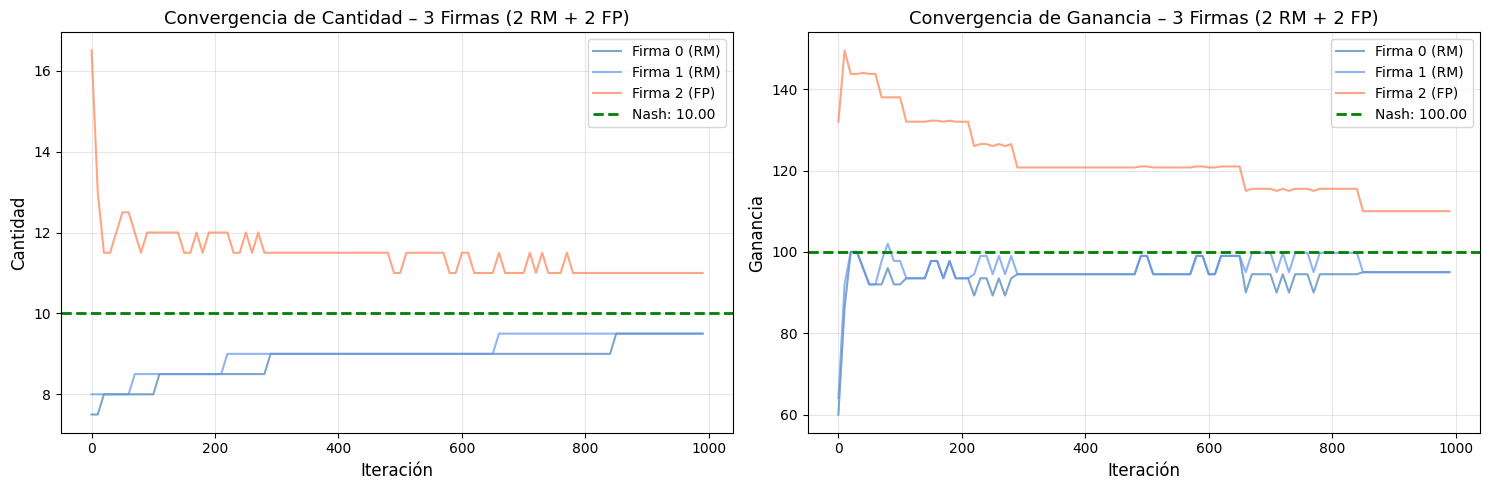

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
x = range(0, ITERS_MED3, 10)

rm_colors = ['steelblue', '#EA80FC']
fp_colors = ['coral', 'tomato']

for i, agent in enumerate(g_med3.agents):
    if i < 2:
        color, label = rm_colors[i], f'Firma {i} (RM)'
    else:
        color, label = fp_colors[i - 2], f'Firma {i} (FP)'
    ax1.plot(x, history_mix3['q'][agent], color=color, alpha=0.7, linewidth=1.5, label=label)
    ax2.plot(x, history_mix3['profit'][agent], color=color, alpha=0.7, linewidth=1.5, label=label)

ax1.axhline(y=q_star_med3, color='green', linestyle='--', linewidth=2, label=f'Nash: {q_star_med3:.2f}')
ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Cantidad', fontsize=12)
ax1.set_title('Convergencia de Cantidad – 3 Firmas (2 RM + 2 FP)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(y=profit_star_med3, color='green', linestyle='--', linewidth=2, label=f'Nash: {profit_star_med3:.2f}')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Ganancia', fontsize=12)
ax2.set_title('Convergencia de Ganancia – 3 Firmas (2 RM + 2 FP)', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/experimento_mixto_3firmas_rm_2fp.png', dpi=150, bbox_inches='tight')
plt.show()

## Experimento Mixto: 4 Firmas (2 RM + 2 FP) – Mercado Medio

Se introduce un mercado con **4 firmas** usando los mismos parámetros del Mercado Medio ($a=50$, $b=1$, $c=10$), pero con algoritmos mixtos: las firmas 0 y 1 usan **Regret Matching** y las firmas 2 y 3 usan **Fictitious Play**.

El equilibrio de Nash con 4 firmas es:
$$q^* = \frac{a - c}{(n+1)\,b} = \frac{50 - 10}{5 \cdot 1} = 8$$

Esto permite observar si los dos tipos de agentes convergen al mismo equilibrio cuando comparten el mismo mercado.

In [133]:
# Juego de 4 firmas con parámetros del Mercado Medio
g_med4 = Cournot(a=50.0, b=1.0, c=10.0, n_players=4, max_quantity=25, num_actions=51)
g_med4.reset()

q_star_med4, P_star_med4, profit_star_med4 = g_med4.get_nash_equilibrium()
print(f"Equilibrio de Nash – Mercado Medio, 4 Firmas:")
print(f"  Cantidad por firma  (q*): {q_star_med4:.4f}")
print(f"  Cantidad total      (Q*): {4*q_star_med4:.4f}")
print(f"  Precio              (P*): {P_star_med4:.4f}")
print(f"  Ganancia por firma  (π*): {profit_star_med4:.4f}")

Equilibrio de Nash – Mercado Medio, 4 Firmas:
  Cantidad por firma  (q*): 8.0000
  Cantidad total      (Q*): 32.0000
  Precio              (P*): 18.0000
  Ganancia por firma  (π*): 64.0000


In [134]:
# Firmas 0 y 1 → RM; Firmas 2 y 3 → FP
g_med4.reset()
mixed4_agents = {}
for i, agent in enumerate(g_med4.agents):
    if i < 2:
        mixed4_agents[agent] = RegretMatching(game=g_med4, agent=agent, seed=42)
    else:
        mixed4_agents[agent] = FictitiousPlay(game=g_med4, agent=agent, seed=42)

ITERS_MED4 = 1000
history_mix4 = run_experiment_n(g_med4, mixed4_agents, iterations=ITERS_MED4, breakpoint=5)

print("Estrategias aprendidas (Experimento Mixto – 4 Firmas):")
for i, agent in enumerate(g_med4.agents):
    algo = 'RM' if i < 2 else 'FP'
    q = g_med4._quantities[np.argmax(mixed4_agents[agent].policy())]
    print(f"  Firma {i} ({algo}): q = {q:.4f}  (Nash: {q_star_med4:.4f})")

Iteration 0/1000 | rewards -> agent_0: -33.00, agent_1: -25.50, agent_2: -1.50, agent_3: -2.25


KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
x = range(0, ITERS_MED4, 10)

rm_colors = ['steelblue', 'cornflowerblue']
fp_colors = ['coral', 'tomato']

for i, agent in enumerate(g_med4.agents):
    if i < 2:
        color, label = rm_colors[i], f'Firma {i} (RM)'
    else:
        color, label = fp_colors[i - 2], f'Firma {i} (FP)'
    ax1.plot(x, history_mix4['q'][agent], color=color, alpha=0.7, linewidth=1.5, label=label)
    ax2.plot(x, history_mix4['profit'][agent], color=color, alpha=0.7, linewidth=1.5, label=label)

ax1.axhline(y=q_star_med4, color='green', linestyle='--', linewidth=2, label=f'Nash: {q_star_med4:.2f}')
ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Cantidad', fontsize=12)
ax1.set_title('Convergencia de Cantidad – 4 Firmas (2 RM + 2 FP)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(y=profit_star_med4, color='green', linestyle='--', linewidth=2, label=f'Nash: {profit_star_med4:.2f}')
ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Ganancia', fontsize=12)
ax2.set_title('Convergencia de Ganancia – 4 Firmas (2 RM + 2 FP)', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/experimento_mixto_4firmas_rm_fp.png', dpi=150, bbox_inches='tight')
plt.show()

# Experimento con Parámetros de Mercado Grande – 3 Jugadores

Hasta ahora los experimentos utilizaron parámetros pequeños ($a=25$, $b=2$, $c=1$) con un espacio de acciones reducido (21 cantidades posibles, de 0 a 10). En este experimento se escala el mercado a parámetros más grandes: $a=100$, $b=1$, $c=10$, con **91 acciones** posibles entre 0 y 45 unidades y **3 firmas** competidoras.

El equilibrio de Nash teórico para este mercado es:
$$q^* = \frac{a - c}{(n+1)\,b} = \frac{100 - 18}{4 \cdot 1} = 21$$

El espacio de acción es más de cuatro veces mayor que en los experimentos anteriores. Esto aumenta la dificultad del problema de aprendizaje y permite evaluar cómo escala cada algoritmo ante mercados más complejos. Se prueban los cuatro algoritmos (RM, FP, IQL, JAL-AM).

In [117]:
# Parámetros del mercado grande (3 jugadores)
# a=100, b=1, c=20 → q* = (100-20)/4 = 20 (entero)
g_big = Cournot(a=100.0, b=1.0, c=16.0, n_players=3, max_quantity=40, num_actions=81)
g_big.reset()

q_star_big, P_star_big, profit_star_big = g_big.get_nash_equilibrium()
print(f"Equilibrio de Nash – Mercado Grande, 3 Firmas:")
print(f"  Parámetros: a={g_big.a}, b={g_big.b}, c={g_big.c}, n={g_big.n_players}")
print(f"  Acciones disponibles: {g_big._num_actions}  (paso = {g_big.max_quantity / (g_big._num_actions - 1):.2f})")
print(f"  Cantidad por firma  (q*): {int(q_star_big)}")
print(f"  Cantidad total      (Q*): {int(3*q_star_big)}")
print(f"  Precio              (P*): {int(P_star_big)}")
print(f"  Ganancia por firma  (π*): {int(profit_star_big)}")

Equilibrio de Nash – Mercado Grande, 3 Firmas:
  Parámetros: a=100.0, b=1.0, c=16.0, n=3
  Acciones disponibles: 81  (paso = 0.50)
  Cantidad por firma  (q*): 21
  Cantidad total      (Q*): 63
  Precio              (P*): 37
  Ganancia por firma  (π*): 441


## Regret Matching – Mercado Grande

In [118]:
ITERS_BIG = 2000

g_big.reset()
rm_big = dict(map(lambda agent: (agent, RegretMatching(game=g_big, agent=agent, seed=42)), g_big.agents))
history_rm_big = run_experiment_n(g_big, rm_big, iterations=ITERS_BIG)
print_strategy(g_big, rm_big, 'Regret Matching – Mercado Grande', q_star_big)

Iteration 0/2000 | rewards -> agent_0: 450.00, agent_1: 162.00, agent_2: 576.00
Iteration 50/2000 | rewards -> agent_0: 451.50, agent_1: 440.75, agent_2: 451.50
Iteration 100/2000 | rewards -> agent_0: 441.00, agent_1: 420.00, agent_2: 462.00
Iteration 150/2000 | rewards -> agent_0: 440.75, agent_1: 451.50, agent_2: 451.50
Iteration 200/2000 | rewards -> agent_0: 440.75, agent_1: 451.50, agent_2: 451.50
Iteration 250/2000 | rewards -> agent_0: 441.00, agent_1: 430.50, agent_2: 451.50
Iteration 300/2000 | rewards -> agent_0: 430.50, agent_1: 420.25, agent_2: 451.00
Iteration 350/2000 | rewards -> agent_0: 441.00, agent_1: 441.00, agent_2: 441.00
Iteration 400/2000 | rewards -> agent_0: 451.50, agent_1: 440.75, agent_2: 451.50
Iteration 450/2000 | rewards -> agent_0: 462.00, agent_1: 451.00, agent_2: 451.00
Iteration 500/2000 | rewards -> agent_0: 451.50, agent_1: 440.75, agent_2: 451.50
Iteration 550/2000 | rewards -> agent_0: 441.00, agent_1: 430.50, agent_2: 451.50
Iteration 600/2000 

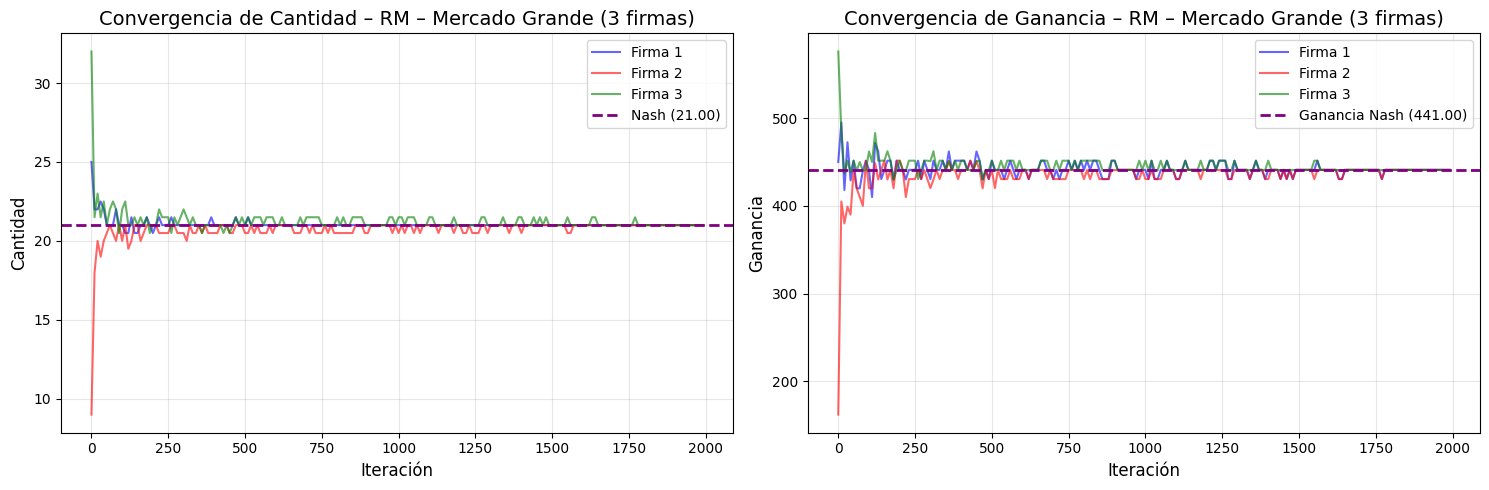

In [122]:
plot_convergence_n(g_big, history_rm_big, ITERS_BIG, 10, q_star_big, profit_star_big,
                   'RM – Mercado Grande (3 firmas)',
                   save_path=f'{SAVE_DIR}/convergencia_rm_3j_grande.png')

## Fictitious Play – Mercado Grande

In [119]:
ITERS_BIG = 2000
g_big.reset()
fp_big = dict(map(lambda agent: (agent, FictitiousPlay(game=g_big, agent=agent, seed=42)), g_big.agents))
history_fp_big = run_experiment_n(g_big, fp_big, iterations=ITERS_BIG, breakpoint=20)
print_strategy(g_big, fp_big, 'Fictitious Play – Mercado Grande', q_star_big)

Iteration 0/2000 | rewards -> agent_0: 396.00, agent_1: 387.00, agent_2: 405.00
Iteration 20/2000 | rewards -> agent_0: 396.00, agent_1: 387.00, agent_2: 405.00
Iteration 40/2000 | rewards -> agent_0: 407.00, agent_1: 397.75, agent_2: 407.00
Iteration 60/2000 | rewards -> agent_0: 407.00, agent_1: 397.75, agent_2: 407.00
Iteration 80/2000 | rewards -> agent_0: 407.00, agent_1: 397.75, agent_2: 407.00
Iteration 100/2000 | rewards -> agent_0: 407.00, agent_1: 397.75, agent_2: 407.00
Iteration 120/2000 | rewards -> agent_0: 407.00, agent_1: 397.75, agent_2: 407.00
Iteration 140/2000 | rewards -> agent_0: 408.50, agent_1: 408.50, agent_2: 418.00
Iteration 160/2000 | rewards -> agent_0: 419.25, agent_1: 409.50, agent_2: 429.00
Iteration 180/2000 | rewards -> agent_0: 419.25, agent_1: 409.50, agent_2: 429.00
Iteration 200/2000 | rewards -> agent_0: 430.00, agent_1: 420.00, agent_2: 430.00
Iteration 220/2000 | rewards -> agent_0: 430.00, agent_1: 420.00, agent_2: 430.00
Iteration 240/2000 | r

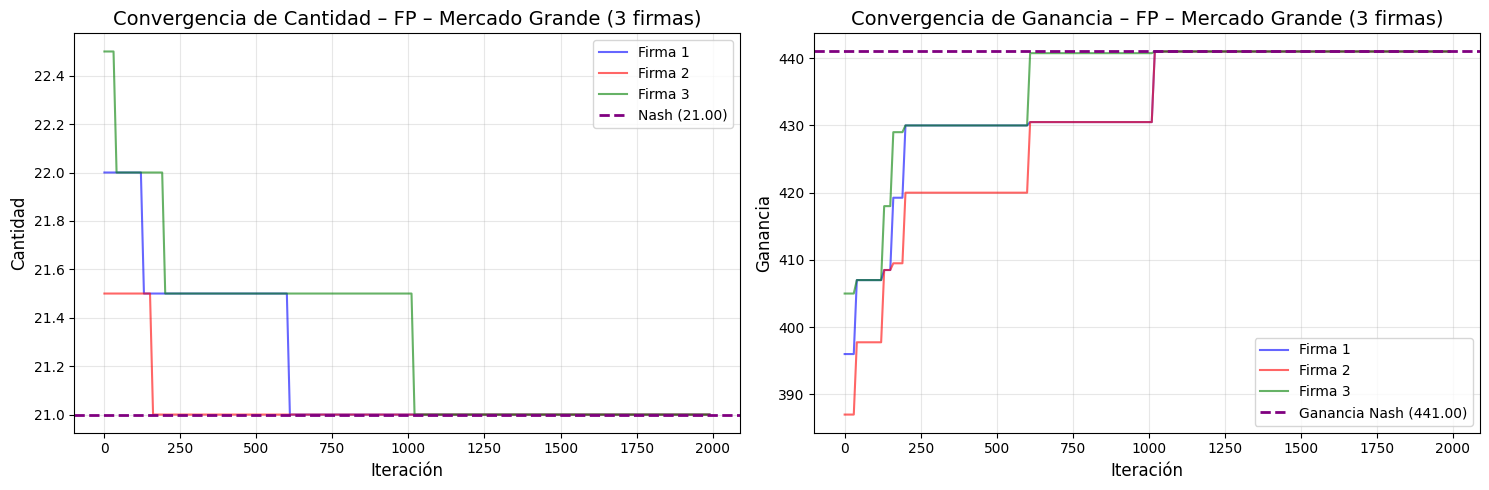

In [120]:
plot_convergence_n(g_big, history_fp_big, ITERS_BIG, 10, q_star_big, profit_star_big,
                   'FP – Mercado Grande (3 firmas)',
                   save_path=f'{SAVE_DIR}/convergencia_fp_3j_grande.png')

## Distribuciones de Estrategia – RM y FP – Mercado Grande (3 Firmas)

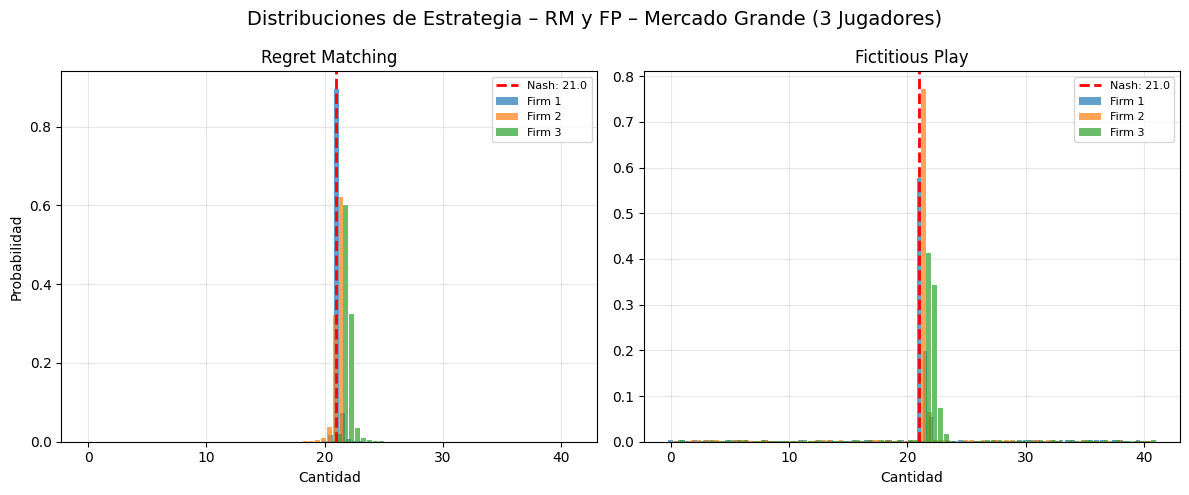

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
algo_info_big = [('Regret Matching', rm_big), ('Fictitious Play', fp_big)]

for ax, (name, agents_dict) in zip(axes, algo_info_big):
    for j, agent in enumerate(g_big.agents):
        policy = agents_dict[agent].policy()
        ax.bar(g_big._quantities + j * 0.4, policy, alpha=0.7, label=f'Firm {j+1}', width=0.4)
    ax.axvline(x=q_star_big, color='red', linestyle='--', linewidth=2, label=f'Nash: {q_star_big:.1f}')
    ax.set_xlabel('Cantidad', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Probabilidad', fontsize=10)
plt.suptitle('Distribuciones de Estrategia – RM y FP – Mercado Grande (3 Jugadores)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/distribuciones_estrategia_3jugadores_grande.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparación Final de Algoritmos

RM y FP se evalúan en 2 y 3 jugadores. IQL y JAL-AM solo se evalúan en 2 jugadores: dado que no convergen al Nash en ese escenario más simple, no tiene sentido extender el experimento a 3 jugadores.

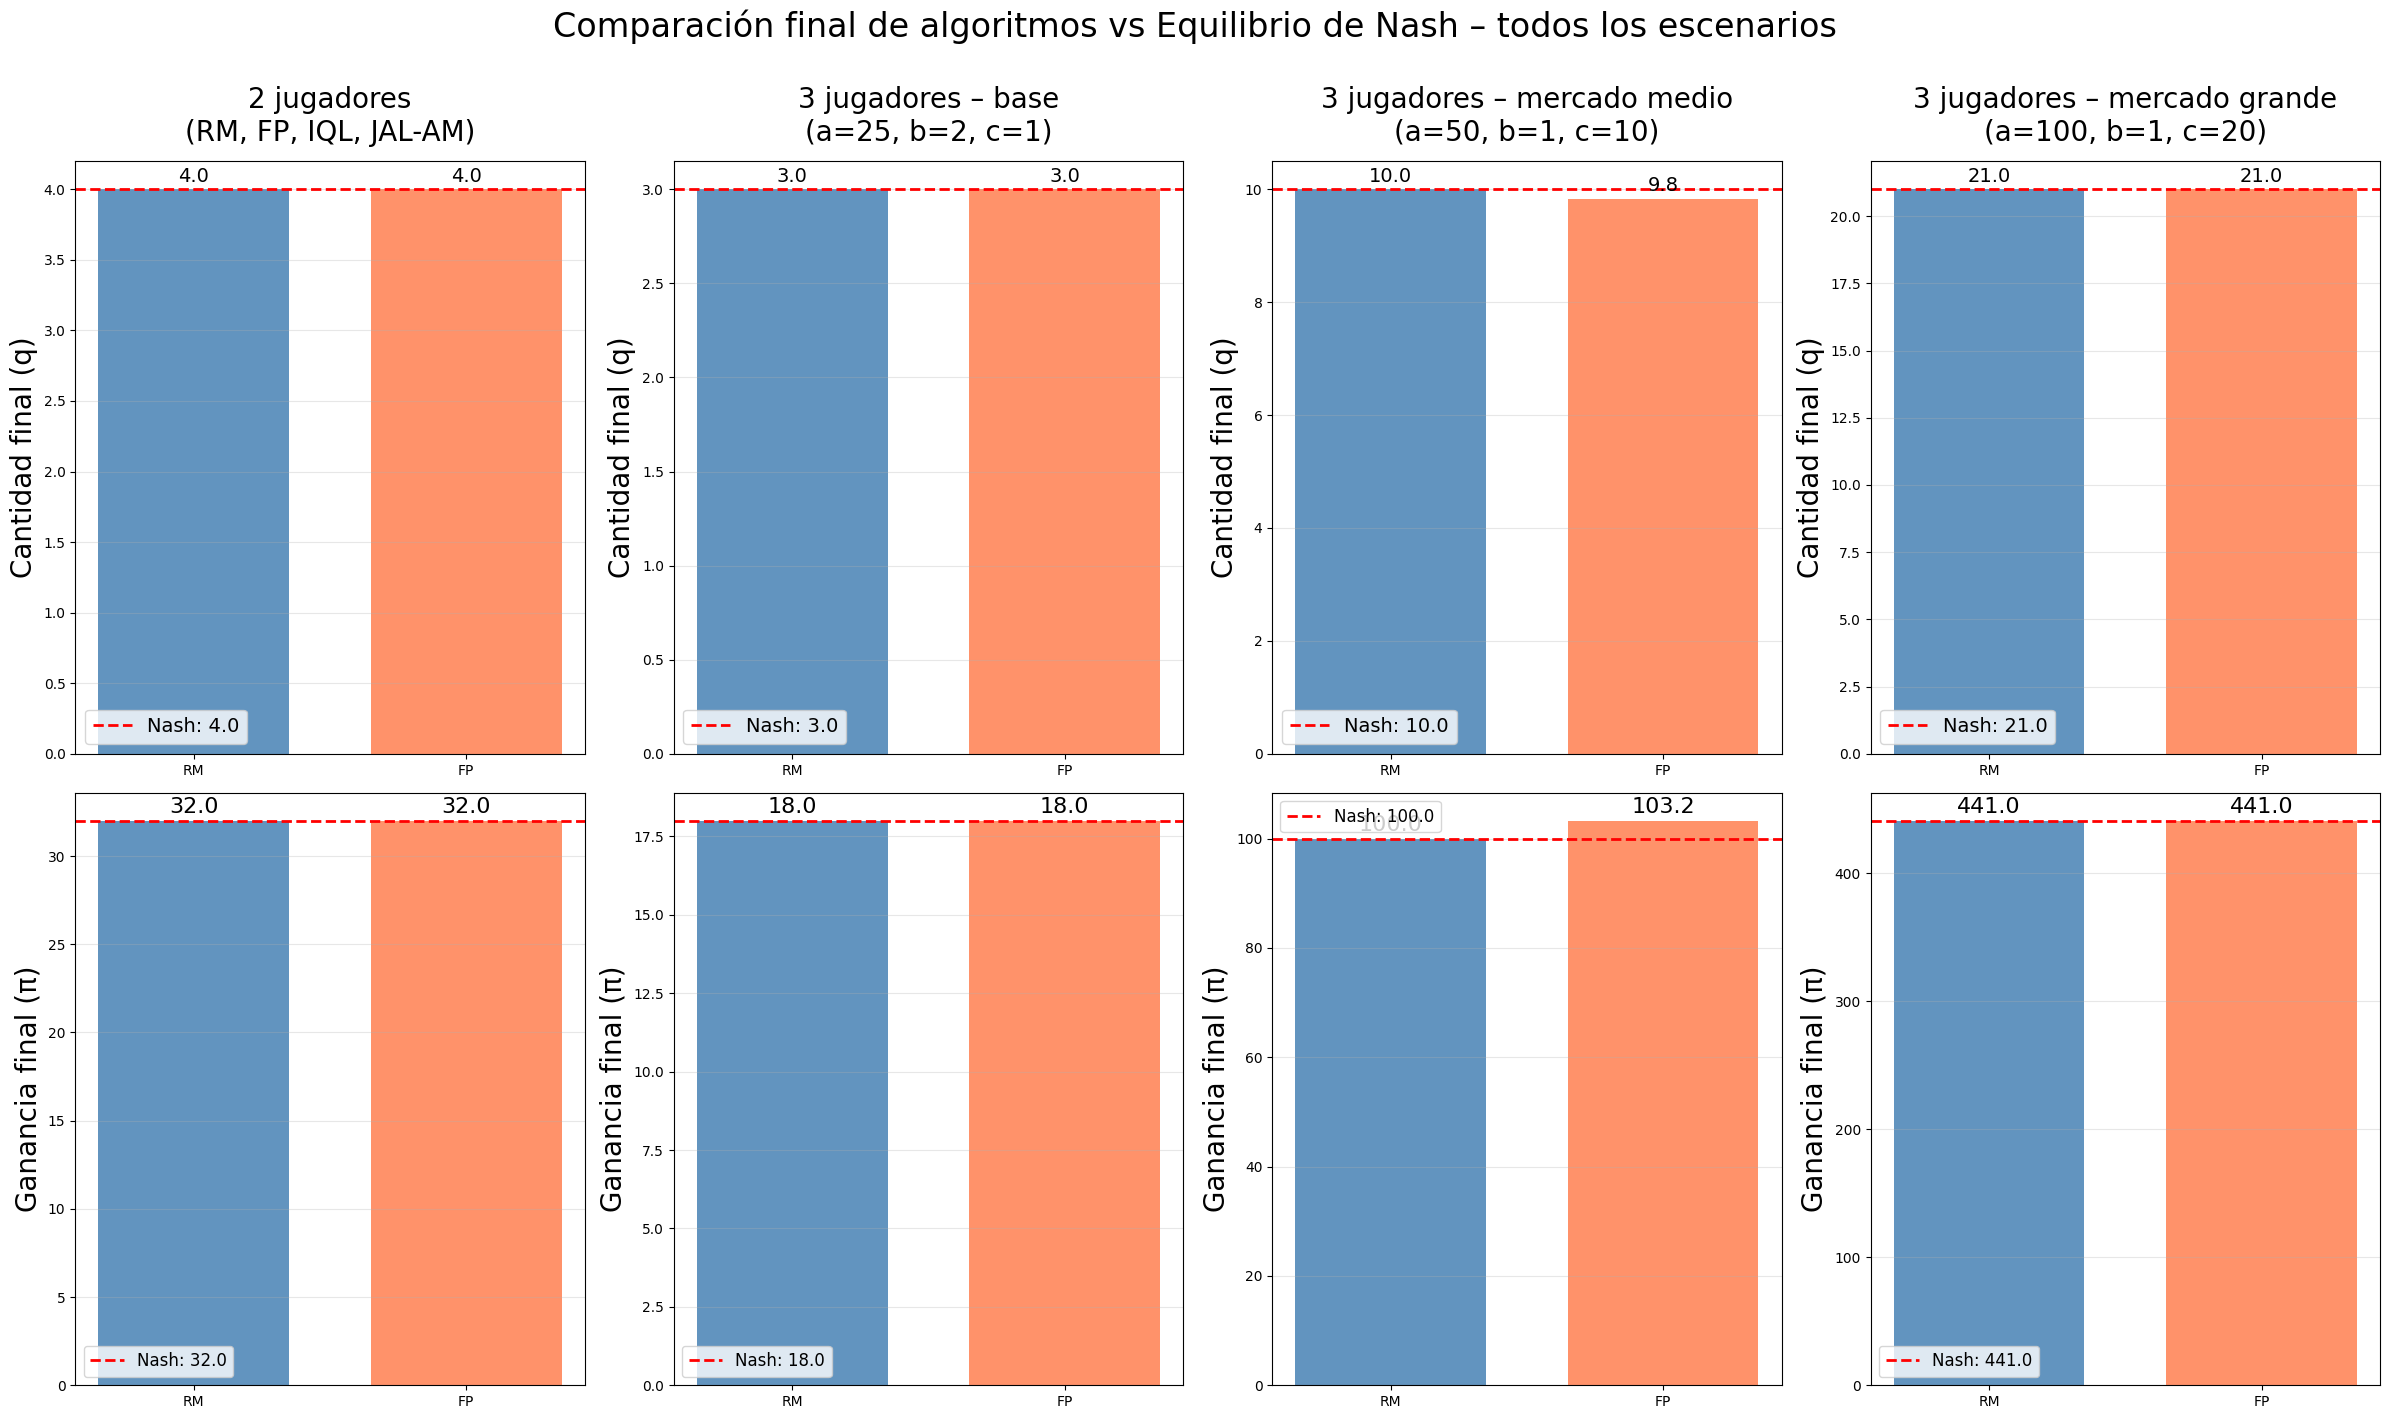

In [123]:
# 2 jugadores: todos los algoritmos
algo_names_2p = ['RM', 'FP']
colors_2p     = ['steelblue', 'coral']
agents_2p     = [rm, fp]

# 3 jugadores: solo RM y FP
algo_names_3p = ['RM', 'FP']
colors_3p     = ['steelblue', 'coral']

def get_final_q_each(game, agents_dict):
    """Cantidad final promedio entre todas las firmas."""
    qs = [game._quantities[np.argmax(agents_dict[ag].policy())] for ag in game.agents]
    return np.mean(qs)

def get_avg_profit_each(game, agents_dict):
    quantities = {ag: game._quantities[np.argmax(agents_dict[ag].policy())] for ag in game.agents}
    q_total = sum(quantities.values())
    return np.mean([game._compute_profit(quantities[ag], q_total) for ag in game.agents])

final_q_2p   = [get_final_q_each(g,     a) for a in agents_2p]
final_q_3p   = [get_final_q_each(g3,    a) for a in [rm3, fp3]]
final_q_med  = [get_final_q_each(g_med, a) for a in [rm_med, fp_med]]
final_q_big  = [get_final_q_each(g_big, a) for a in [rm_big, fp_big]]

final_p_2p   = [get_avg_profit_each(g,     a) for a in agents_2p]
final_p_3p   = [get_avg_profit_each(g3,    a) for a in [rm3, fp3]]
final_p_med  = [get_avg_profit_each(g_med, a) for a in [rm_med, fp_med]]
final_p_big  = [get_avg_profit_each(g_big, a) for a in [rm_big, fp_big]]

BAR_W = 0.7

fig, axes = plt.subplots(2, 4, figsize=(24, 14))

scenarios = [
    (axes[0,0], axes[1,0], final_q_2p,  final_p_2p,  algo_names_2p, colors_2p,
     q_star,     profit_star,    '2 jugadores\n(RM, FP, IQL, JAL-AM)'),
    (axes[0,1], axes[1,1], final_q_3p,  final_p_3p,  algo_names_3p, colors_3p,
     q_star_3,   profit_star_3,  '3 jugadores – base\n(a=25, b=2, c=1)'),
    (axes[0,2], axes[1,2], final_q_med, final_p_med, algo_names_3p, colors_3p,
     q_star_med, profit_star_med,'3 jugadores – mercado medio\n(a=50, b=1, c=10)'),
    (axes[0,3], axes[1,3], final_q_big, final_p_big, algo_names_3p, colors_3p,
     q_star_big, profit_star_big,'3 jugadores – mercado grande\n(a=100, b=1, c=20)'),
]

for ax_q, ax_p, q_vals, p_vals, names, colors, nash_q, nash_p, title in scenarios:
    bars_q = ax_q.bar(names, q_vals, color=colors, alpha=0.85, width=BAR_W)
    ax_q.axhline(y=nash_q, color='red', linestyle='--', linewidth=2, label=f'Nash: {nash_q:.1f}')
    ax_q.legend(fontsize=14)
    ax_q.set_title(title, fontsize=20, y=1.02)
    ax_q.set_ylabel('Cantidad final (q)',  fontsize=20)
    ax_q.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars_q, q_vals):
        ax_q.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + nash_q * 0.006,
                  f'{v:.1f}', ha='center', va='bottom', fontsize=14)

    bars_p = ax_p.bar(names, p_vals, color=colors, alpha=0.85, width=BAR_W)
    ax_p.axhline(y=nash_p, color='red', linestyle='--', linewidth=2, label=f'Nash: {nash_p:.1f}')
    ax_p.legend(fontsize=12)
    ax_p.set_ylabel('Ganancia final (π)', fontsize=20)
    ax_p.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars_p, p_vals):
        y_label = max(bar.get_height(), 0) + nash_p * 0.006
        ax_p.text(bar.get_x() + bar.get_width()/2, y_label,
                  f'{v:.1f}', ha='center', va='bottom', fontsize=16)

plt.suptitle('Comparación final de algoritmos vs Equilibrio de Nash – todos los escenarios', fontsize=24, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparacion_final_algoritmos.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusiones

- En el juego de Cournot, el equilibrio de Nash ocurre cuando ninguna firma tiene incentivos a cambiar unilateralmente su cantidad producida. En nuestros experimentos, esto ocurre en $q^* = 4$ para 2 jugadores y en $q^* = 3$ para 3 jugadores.

- De acuerdo con la performance observada para cada agente, podemos concluir:

    - **Random Agent**: funciona como baseline y confirma que, sin aprendizaje, no aparece ningún tipo de coordinación ni convergencia estable.

    - **Independent Q-Learning (IQL)**: fue uno de los agentes más inestables. Debido a la no-estacionariedad del entorno multiagente, el algoritmo no logra converger correctamente y suele estabilizarse en cantidades cercanas a $q \approx 3.5$, que no corresponden al equilibrio de Nash.

     - **JAL-AM**: performó mejor que IQL porque modela explícitamente las acciones del oponente, pero igualmente presentó oscilaciones y no logró converger al equilibrio de Nash de forma consistente.

    - **Fictitious Play (FP)**: aproximó correctamente el equilibrio de Nash tanto en 2 como en 3 jugadores. Fue uno de los algoritmos más estables, aunque necesitó más iteraciones para converger porque depende de estimar la estrategia histórica del oponente.

    - **Regret Matching (RM)**: performó de manera muy similar a FP y fue uno de los agentes que mejor capturó el comportamiento esperado teóricamente para Cournot.
    
    - (**RM vs FP**), RM converge más rápido que FP. Esto tiene sentido porque RM empieza a ajustar su estrategia usando regrets acumulados desde el inicio, mientras que FP necesita observar suficientes jugadas del oponente para construir una buena estimación de su política.

- Algo interesante observado en IQL y JAL-AM es que, aunque a veces alcanzan recompensas mayores que las del equilibrio de Nash, eso no implica que hayan encontrado una solución estable. Los agentes pueden quedar temporalmente en regiones que parecen buenas, pero donde cualquier pequeño cambio en la estrategia de uno de los jugadores hace que el otro tenga incentivos a desviarse.

- En general, RM y FP fueron los algoritmos que mejor capturaron el comportamiento esperado teóricamente para Cournot, mientras que IQL y JAL-AM reflejaron las dificultades clásicas de aprendizaje por refuerzo en entornos multiagente no estacionarios.